In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import re
from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
from collections import defaultdict

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import torch
from torchnmf.nmf import NMF

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

# Load our data

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata_raw = sc.read_h5ad(fpath)
adata_raw.X = adata_raw.layers['raw_counts'].copy()
adata_raw.obs['dataset'] = 'sample'
adata_raw

CPU times: user 379 ms, sys: 2.65 s, total: 3.03 s
Wall time: 5.56 s


AnnData object with n_obs × n_vars = 15867 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'dataset'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions',

In [3]:
%%time

agg = 'sum'
sdata = sc.get.aggregate(
    adata_raw,
    by='cluster_str',
    func=agg,
    layer='raw_counts',
)

sdata.X = sdata.layers[agg]
sdata.obs['dataset'] = 'sample'

print("-> GPU: rdata"); rsc.get.anndata_to_GPU(sdata)
print("-> Normalize/log: sdata")
rsc.pp.normalize_total(sdata, target_sum=1e4)
rsc.pp.log1p(sdata)
print("-> CPU: rdata"); rsc.get.anndata_to_CPU(sdata)


print(f"{sdata.shape=}")
sdata.obs.head()

-> GPU: rdata
-> Normalize/log: sdata
-> CPU: rdata
sdata.shape=(5, 21412)
CPU times: user 178 ms, sys: 12.1 ms, total: 190 ms
Wall time: 474 ms


,cluster_str,dataset
C1,C1,sample
C2,C2,sample
C3,C3,sample
C4,C4,sample
C5,C5,sample


# Load other datasets

In [4]:
# bdata = sc.read_h5ad("/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/setty_2019/human_cd34_bm_rep2.h5ad")
# bdata

In [5]:
datasets = {
    'Gomes 2018' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/gomes_2018/gomes.h5ad",
        'annotation_column' : 'cell_type',
        'layer' : 'raw_counts',
    },
    'Pellin 2019' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/pellin_2019/pellin.anndata.h5ad",
        'annotation_column' : 'dataset',
        'layer' : 'raw_counts',
    },
    'Georgolopoulos 2021' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/georgolopoulos_2021/anndata.h5ad",
        'annotation_column' : 'populations',
        'layer' : 'matrix',
    },
    'Weng 2024' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/weng_2024/scanpy_objects/young1_all_t2.h5ad",
        'annotation_column' : 'STD.CellType',
        'layer' : 'raw_counts',
    },

    'Ng 2024' : {
        'file_path' : "/nfs/turbo/umms-indikar/shared/projects/HSC/data/datasets/ng_2024/iHSC.h5ad",
        'annotation_column' : 'celltype',
        'layer' : None,
    },
}

In [6]:
%%time
data = {}
metadata = []

for dataset, params in tqdm(datasets.items(), "Load data"):
    t0 = time.time()
    fpath = params['file_path']
    column = params['annotation_column']
    layer = params['layer']

    t1 = time.time()
    bdata = sc.read_h5ad(fpath)
    t2 = time.time()
    bdata.obs['cell_type'] = bdata.obs[column].copy()
    bdata = bdata[bdata.obs['cell_type'].notna(), :].copy()
    if layer is not None:
        bdata.X = bdata.layers[layer].copy()

    bdata.var_names_make_unique()

    n_cells = bdata.shape[0]
    n_genes_raw = bdata.shape[1]
    t3 = time.time()

    bdata = bdata[:, bdata.var_names.isin(adata_raw.var_names)].copy()
    n_genes_filtered = bdata.shape[1]
    n_cell_types = bdata.obs['cell_type'].nunique()
    cell_types = sorted(bdata.obs['cell_type'].unique())
    t4 = time.time()

    # Save results to metadata
    metadata.append({
        "dataset": dataset,
        "load_time": t2-t1,
        "total_time": t4-t0,
        "n_cells": n_cells,
        "n_genes_raw": n_genes_raw,
        "n_genes_filtered": n_genes_filtered,
        "n_cell_types": n_cell_types,
    })

    data[dataset] = {'adata' : bdata.copy()}
    # break

# Convert to DataFrame
metadata_df = pd.DataFrame(metadata)
print(metadata_df.to_string(index=False))


Load data:   0%|          | 0/5 [00:00<?, ?it/s]/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
Load data:  40%|████      | 2/5 [00:38<01:08, 22.83s/it]/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them uniq

            dataset  load_time  total_time  n_cells  n_genes_raw  n_genes_filtered  n_cell_types
         Gomes 2018   0.142793    0.258572      286        56269             14967             5
        Pellin 2019   6.877923   32.295286    21412        20582             13986            11
Georgolopoulos 2021  21.767641   34.707597    53511        36601             15791             7
          Weng 2024   2.255894    5.680563    25252        36601             15791            20
            Ng 2024  50.385706   69.855021   252607        27946             14522            20
CPU times: user 1min 30s, sys: 55.9 s, total: 2min 26s
Wall time: 2min 34s


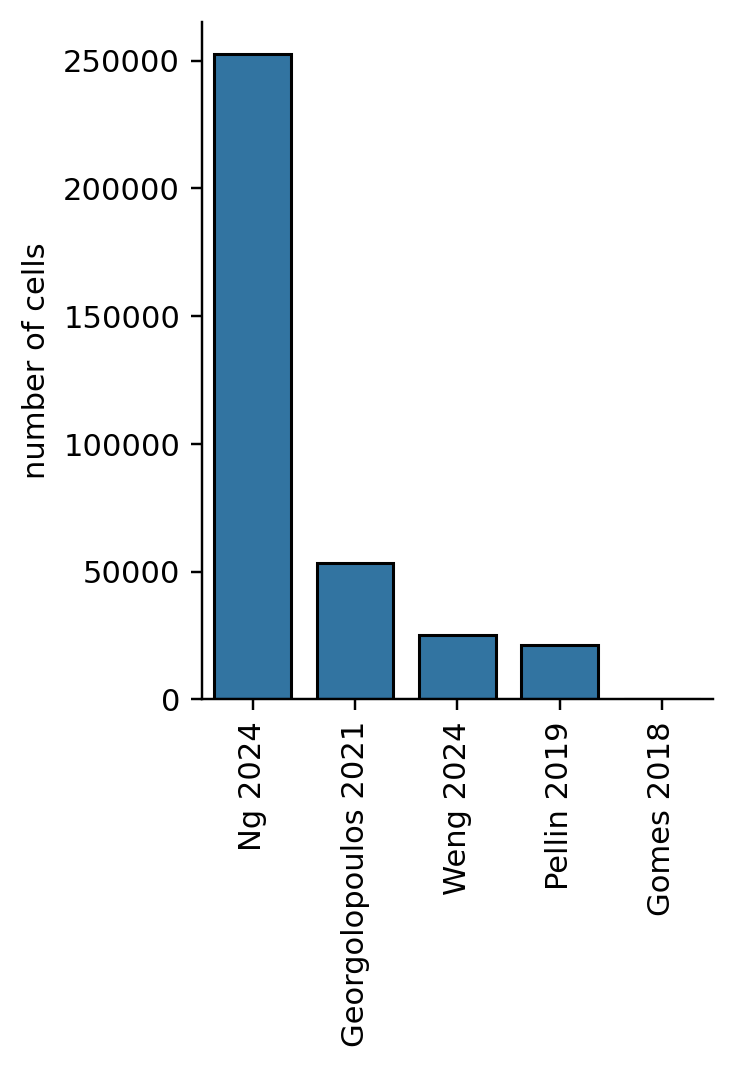

In [7]:
plt.rcParams['figure.dpi'] = 220
plt.rcParams['figure.figsize'] = 3, 4

sns.barplot(
    data=metadata_df.sort_values(by='n_cells', ascending=False,),
    x='dataset',
    y='n_cells',
    ec='k',
    width=0.75,
)

plt.xticks(rotation = 90)
plt.xlabel("")
plt.ylabel("number of cells")
sns.despine()

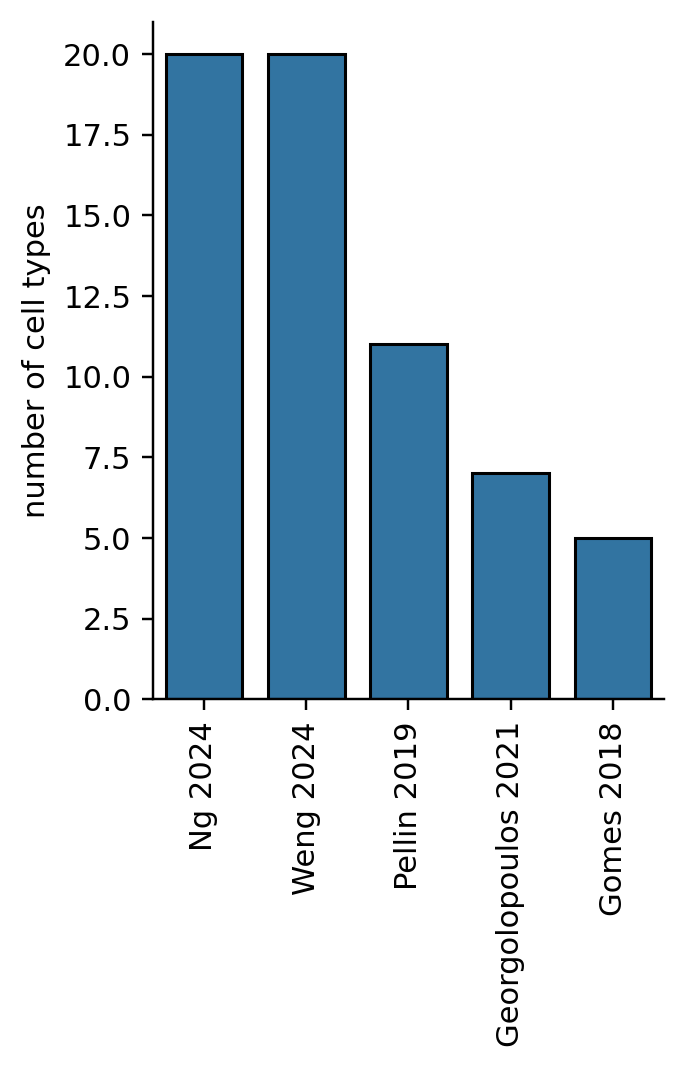

In [8]:
plt.rcParams['figure.dpi'] = 220
plt.rcParams['figure.figsize'] = 3, 4

sns.barplot(
    data=metadata_df.sort_values(by='n_cell_types', ascending=False,),
    x='dataset',
    y='n_cell_types',
    ec='k',
    width=0.75,
)

plt.xticks(rotation = 90)
plt.xlabel("")
plt.ylabel("number of cell types")
sns.despine()

# aggregate

In [9]:
%%time

for dataset, data_dict in tqdm(data.items(), "Load data"):
    agg = 'sum'
    rdata = sc.get.aggregate(
        data_dict['adata'],
        by='cell_type',
        func=agg,
    )
    
    rdata.X = rdata.layers[agg]
    rsc.get.anndata_to_GPU(rdata)
    rsc.pp.normalize_total(rdata, target_sum=1e4)
    rsc.pp.log1p(rdata)
    rsc.get.anndata_to_CPU(rdata)
    data[dataset]['rdata'] = rdata.copy()


print('done!')    

Load data: 100%|██████████| 5/5 [00:28<00:00,  5.69s/it]

done!
CPU times: user 21.5 s, sys: 6.67 s, total: 28.1 s
Wall time: 28.4 s


# Correlations

X.shape=(5, 14967) A.shape=(5, 5)


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


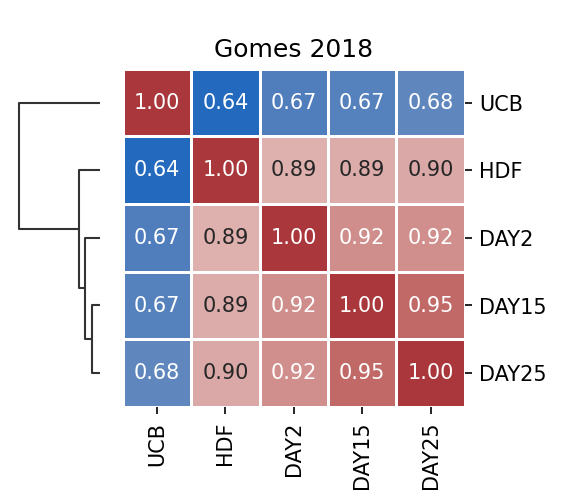

X.shape=(11, 13986) A.shape=(11, 11)


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


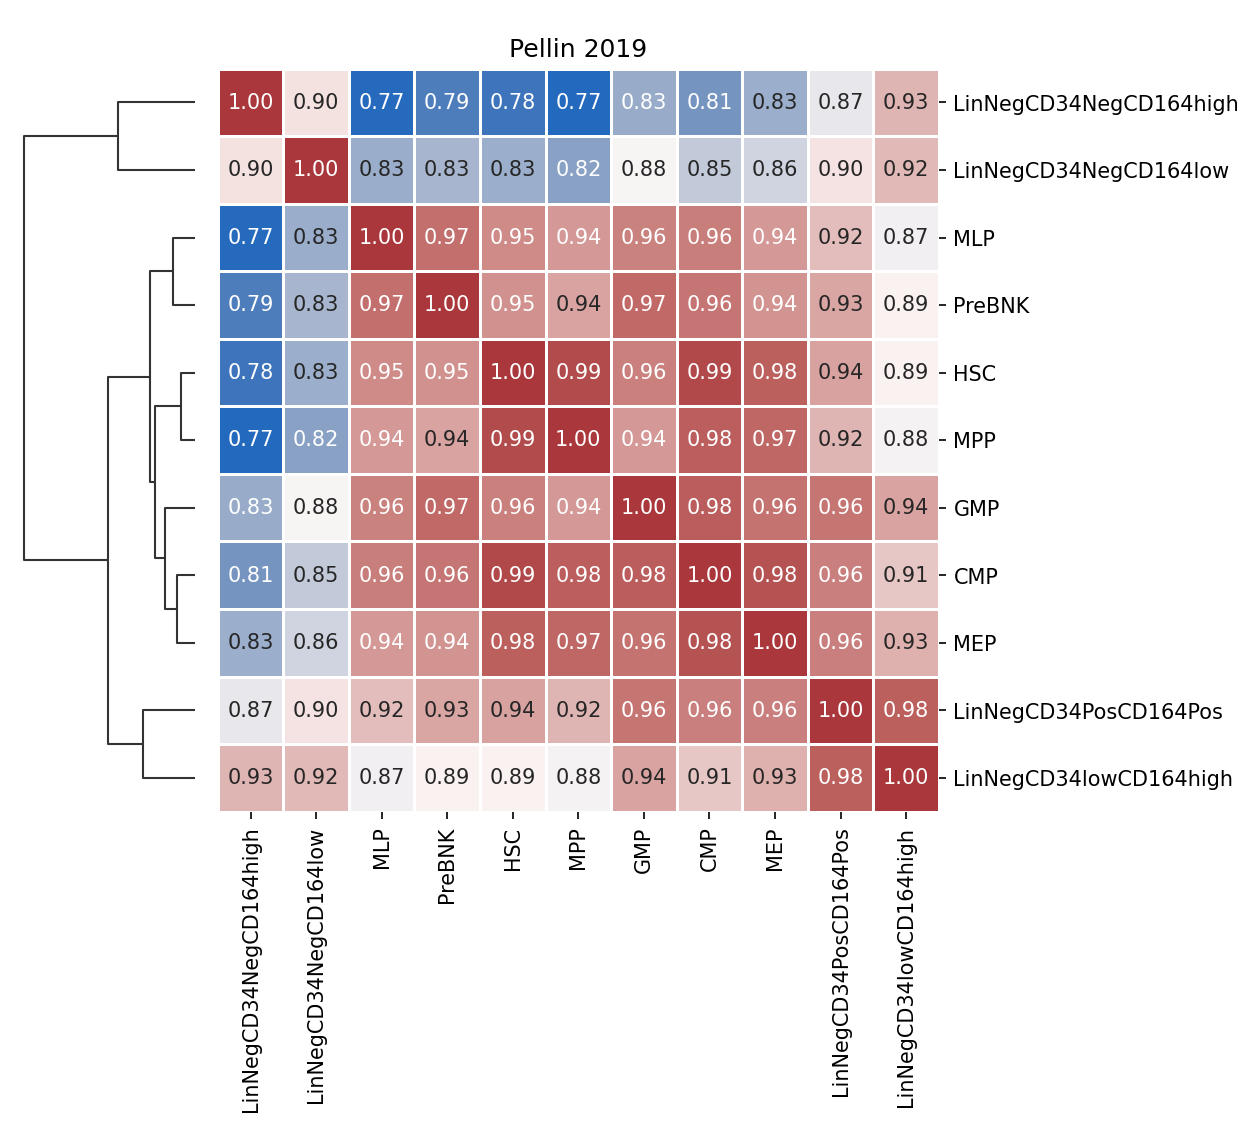

X.shape=(7, 15791) A.shape=(7, 7)


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


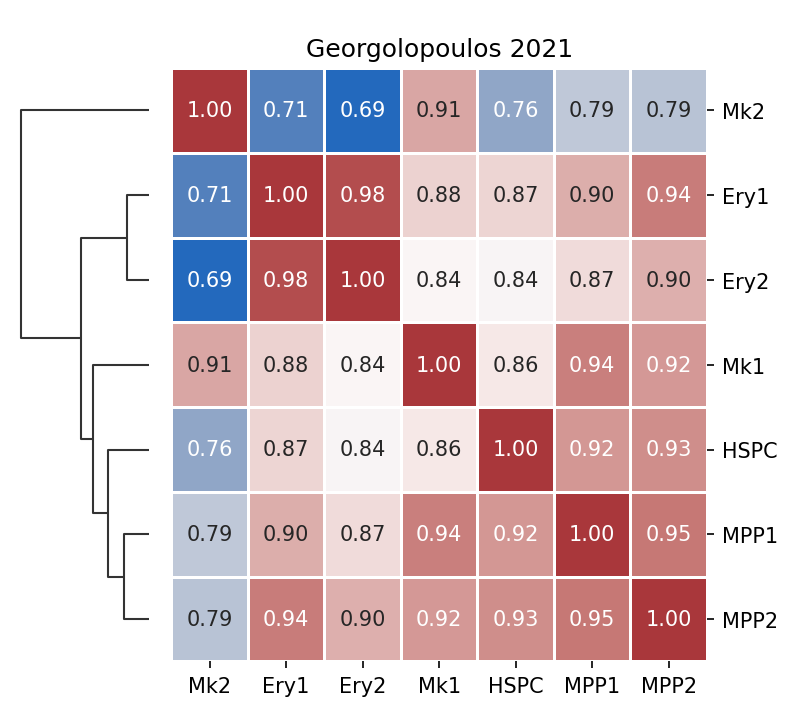

X.shape=(20, 15791) A.shape=(20, 20)


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


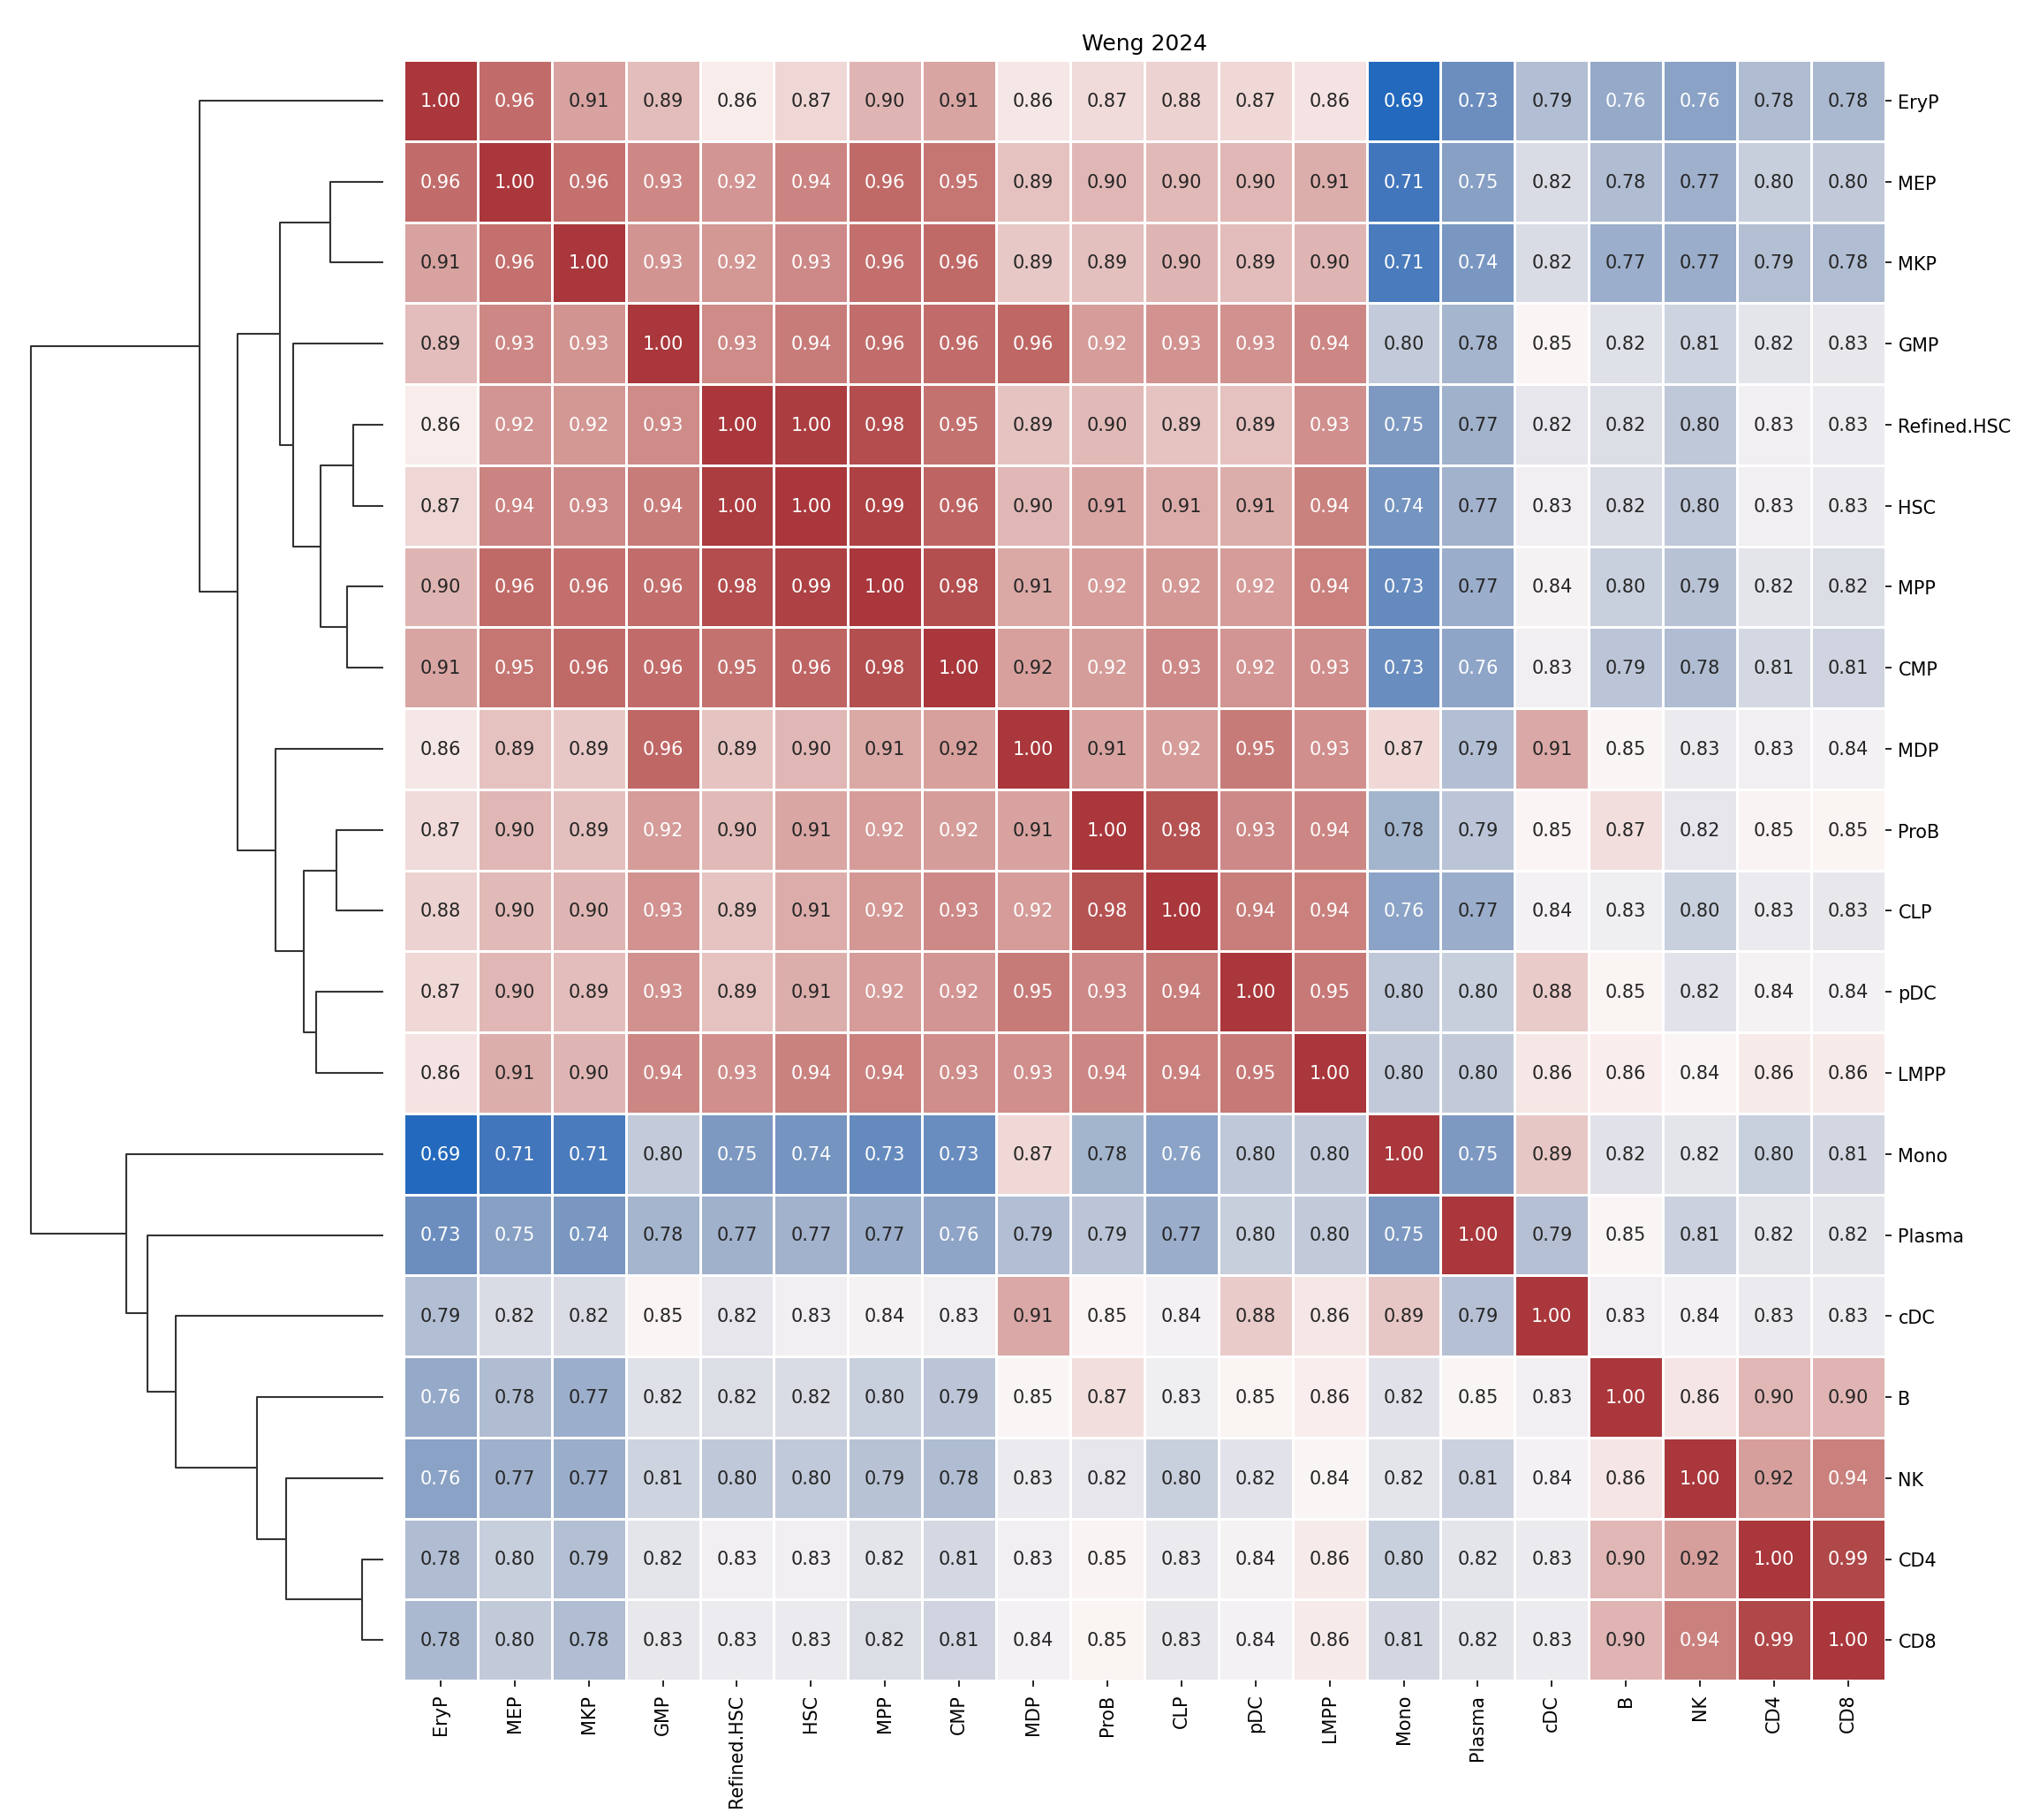

X.shape=(20, 14522) A.shape=(20, 20)


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


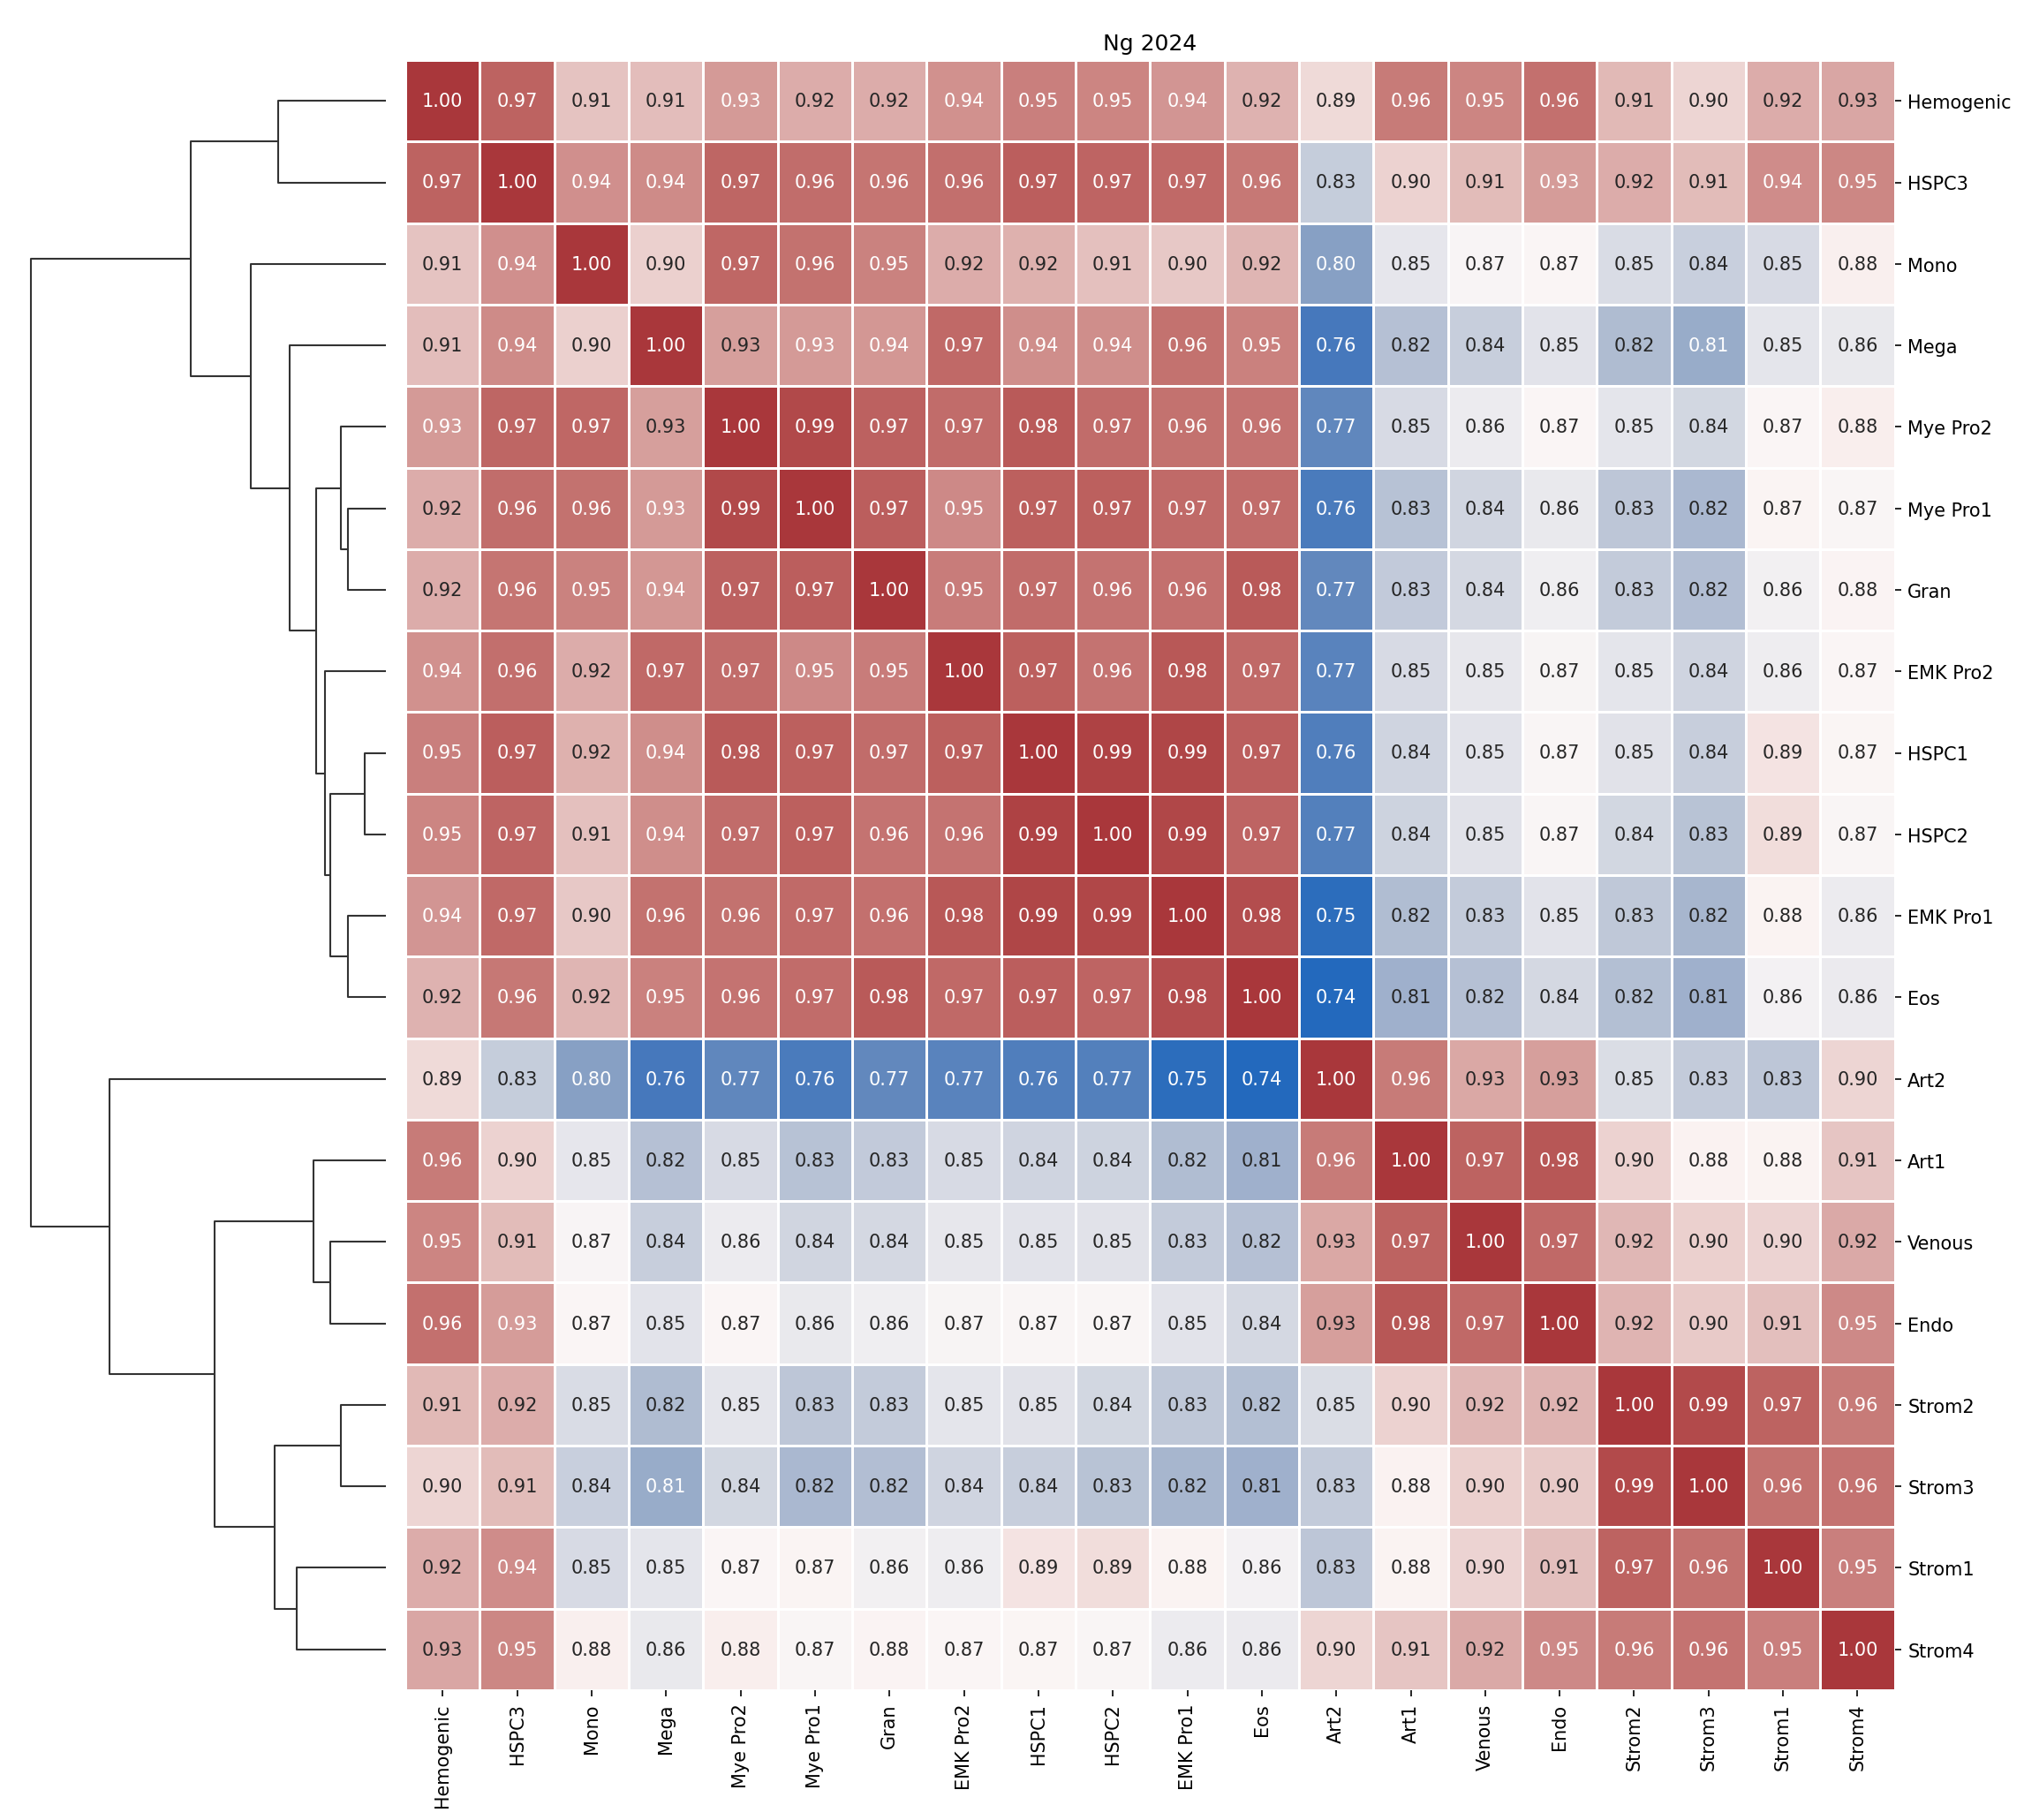

CPU times: user 2.51 s, sys: 531 ms, total: 3.04 s
Wall time: 3.06 s


In [10]:
%%time

for dataset, data_dict in data.items():
    X = data_dict['rdata'].to_df()
    A = X.T.corr()
    print(f"{X.shape=} {A.shape=}")

    plt.rcParams['figure.dpi'] = 150

    xy = A.shape[0] / 1.3
    sns.clustermap(
        A,
        annot=True,
        cmap='vlag',
        square=True,
        linewidths=0.5,
        figsize=(xy, xy*0.9),
        cbar_kws={'label': 'Mean Correlation', 'shrink' : 0.35},
        fmt=".2f",
        dendrogram_ratio=(0.2, 0.0),
        tree_kws={'lw' : 1},
        cbar_pos=None,
    )
    plt.title(dataset)
    plt.yticks(rotation=0)
    plt.ylabel('')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()

# Correlations

In [11]:
def top_percentile_genes_anndata(rdata, sdata, percentile=90):
    """
    Keep only genes in the intersection of rdata and sdata, and restrict to those in the
    top `percentile` mean expression in both datasets.

    rdata, sdata: AnnData objects
    percentile: top percentile to keep (e.g., 90 for top 10%)
    """
    gene_intersection = list(set(rdata.var_names) & set(sdata.var_names))
    X = sdata[:, gene_intersection].X.copy()
    Y = rdata[:, gene_intersection].X.copy()
    
    s_means = np.asarray(X.mean(axis=0)).ravel()
    r_means = np.asarray(Y.mean(axis=0)).ravel()
    s_thresh = np.percentile(s_means, percentile)
    r_thresh = np.percentile(r_means, percentile)
    keep = (s_means >= s_thresh) & (r_means >= r_thresh)
    genes_top = np.array(gene_intersection)[keep]
    return genes_top, X[:, keep], Y[:, keep]

_, X, Y = top_percentile_genes_anndata(rdata, sdata, percentile=25)

In [12]:
%%time
threshold = 25

results = []

for dataset, data_dict in data.items():
    rdata = data_dict['rdata']

    _, X, Y = top_percentile_genes_anndata(rdata, sdata, percentile=threshold)

    # Pairwise correlation matrix (n, k)
    dist = cdist(X, Y, metric='correlation')
    corr = 1 - dist

    # Get obs_names
    s_obs = sdata.obs_names if hasattr(sdata, 'obs_names') else range(X.shape[0])
    r_obs = rdata.obs_names if hasattr(rdata, 'obs_names') else range(Y.shape[0])

    # Build long-form DataFrame
    df = pd.DataFrame(
        corr,
        index=s_obs,
        columns=r_obs
    ).reset_index().melt(
        id_vars='index',
        var_name='r_obs',
        value_name='correlation'
    ).rename(columns={'index': 's_obs'})
    df['dataset'] = dataset

    results.append(df)

results = pd.concat(results, ignore_index=True)
print(results.head().to_string(index=False))

s_obs r_obs  correlation    dataset
   C1  DAY2     0.619755 Gomes 2018
   C2  DAY2     0.586240 Gomes 2018
   C3  DAY2     0.624449 Gomes 2018
   C4  DAY2     0.585541 Gomes 2018
   C5  DAY2     0.592904 Gomes 2018
CPU times: user 131 ms, sys: 8.98 ms, total: 140 ms
Wall time: 141 ms


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Gomes 2018'),
  Text(1, 0, 'Pellin 2019'),
  Text(2, 0, 'Georgolopoulos 2021'),
  Text(3, 0, 'Weng 2024'),
  Text(4, 0, 'Ng 2024')])

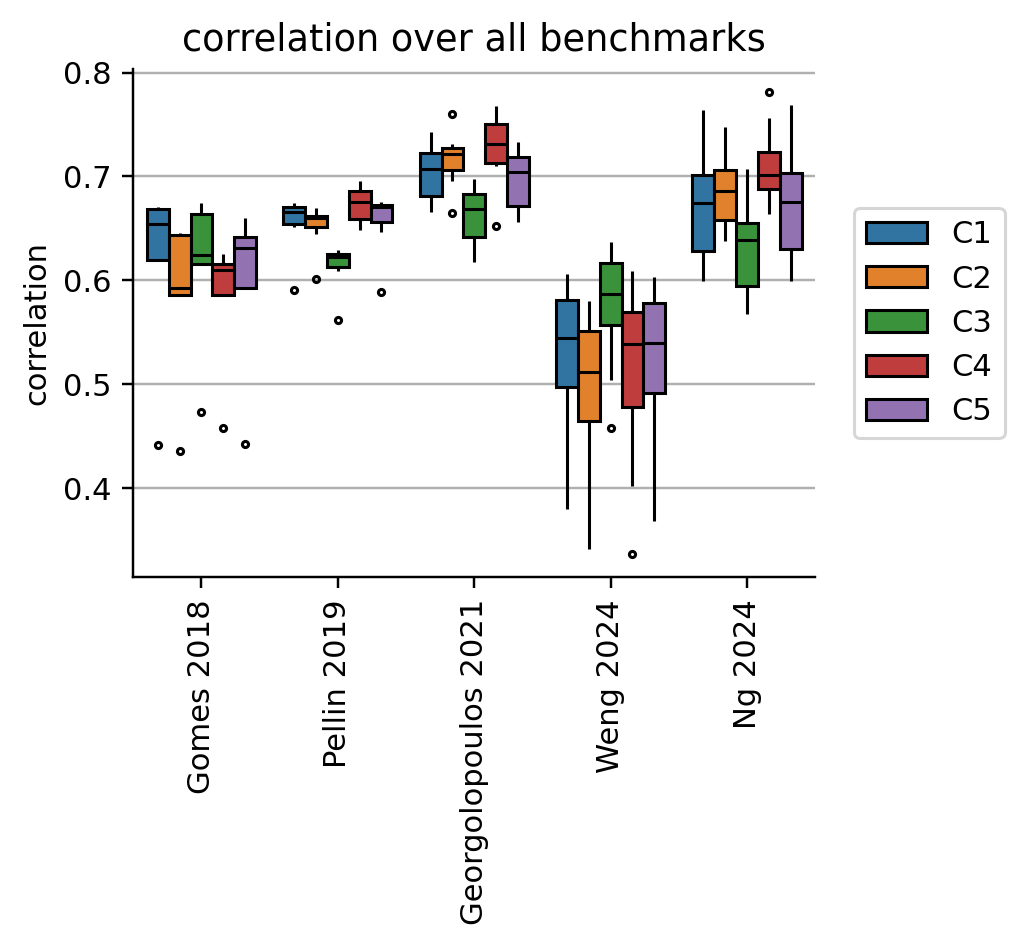

In [13]:
plt.rcParams['figure.dpi'] = 220
plt.rcParams['figure.figsize'] = 4, 3

sns.boxplot(
    data=results,
    x='dataset',
    y='correlation',
    hue='s_obs',
    flierprops={'markersize' : 2},
    capprops={'lw' : 0},
    linecolor='k',
)

plt.title("correlation over all benchmarks")
plt.ylabel("correlation")
plt.xlabel("")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.3, 0.5),
)
sns.despine()
plt.xticks(rotation=90)

pdf.shape=(5, 45)


Text(0.5, -452.9583333333332, '')

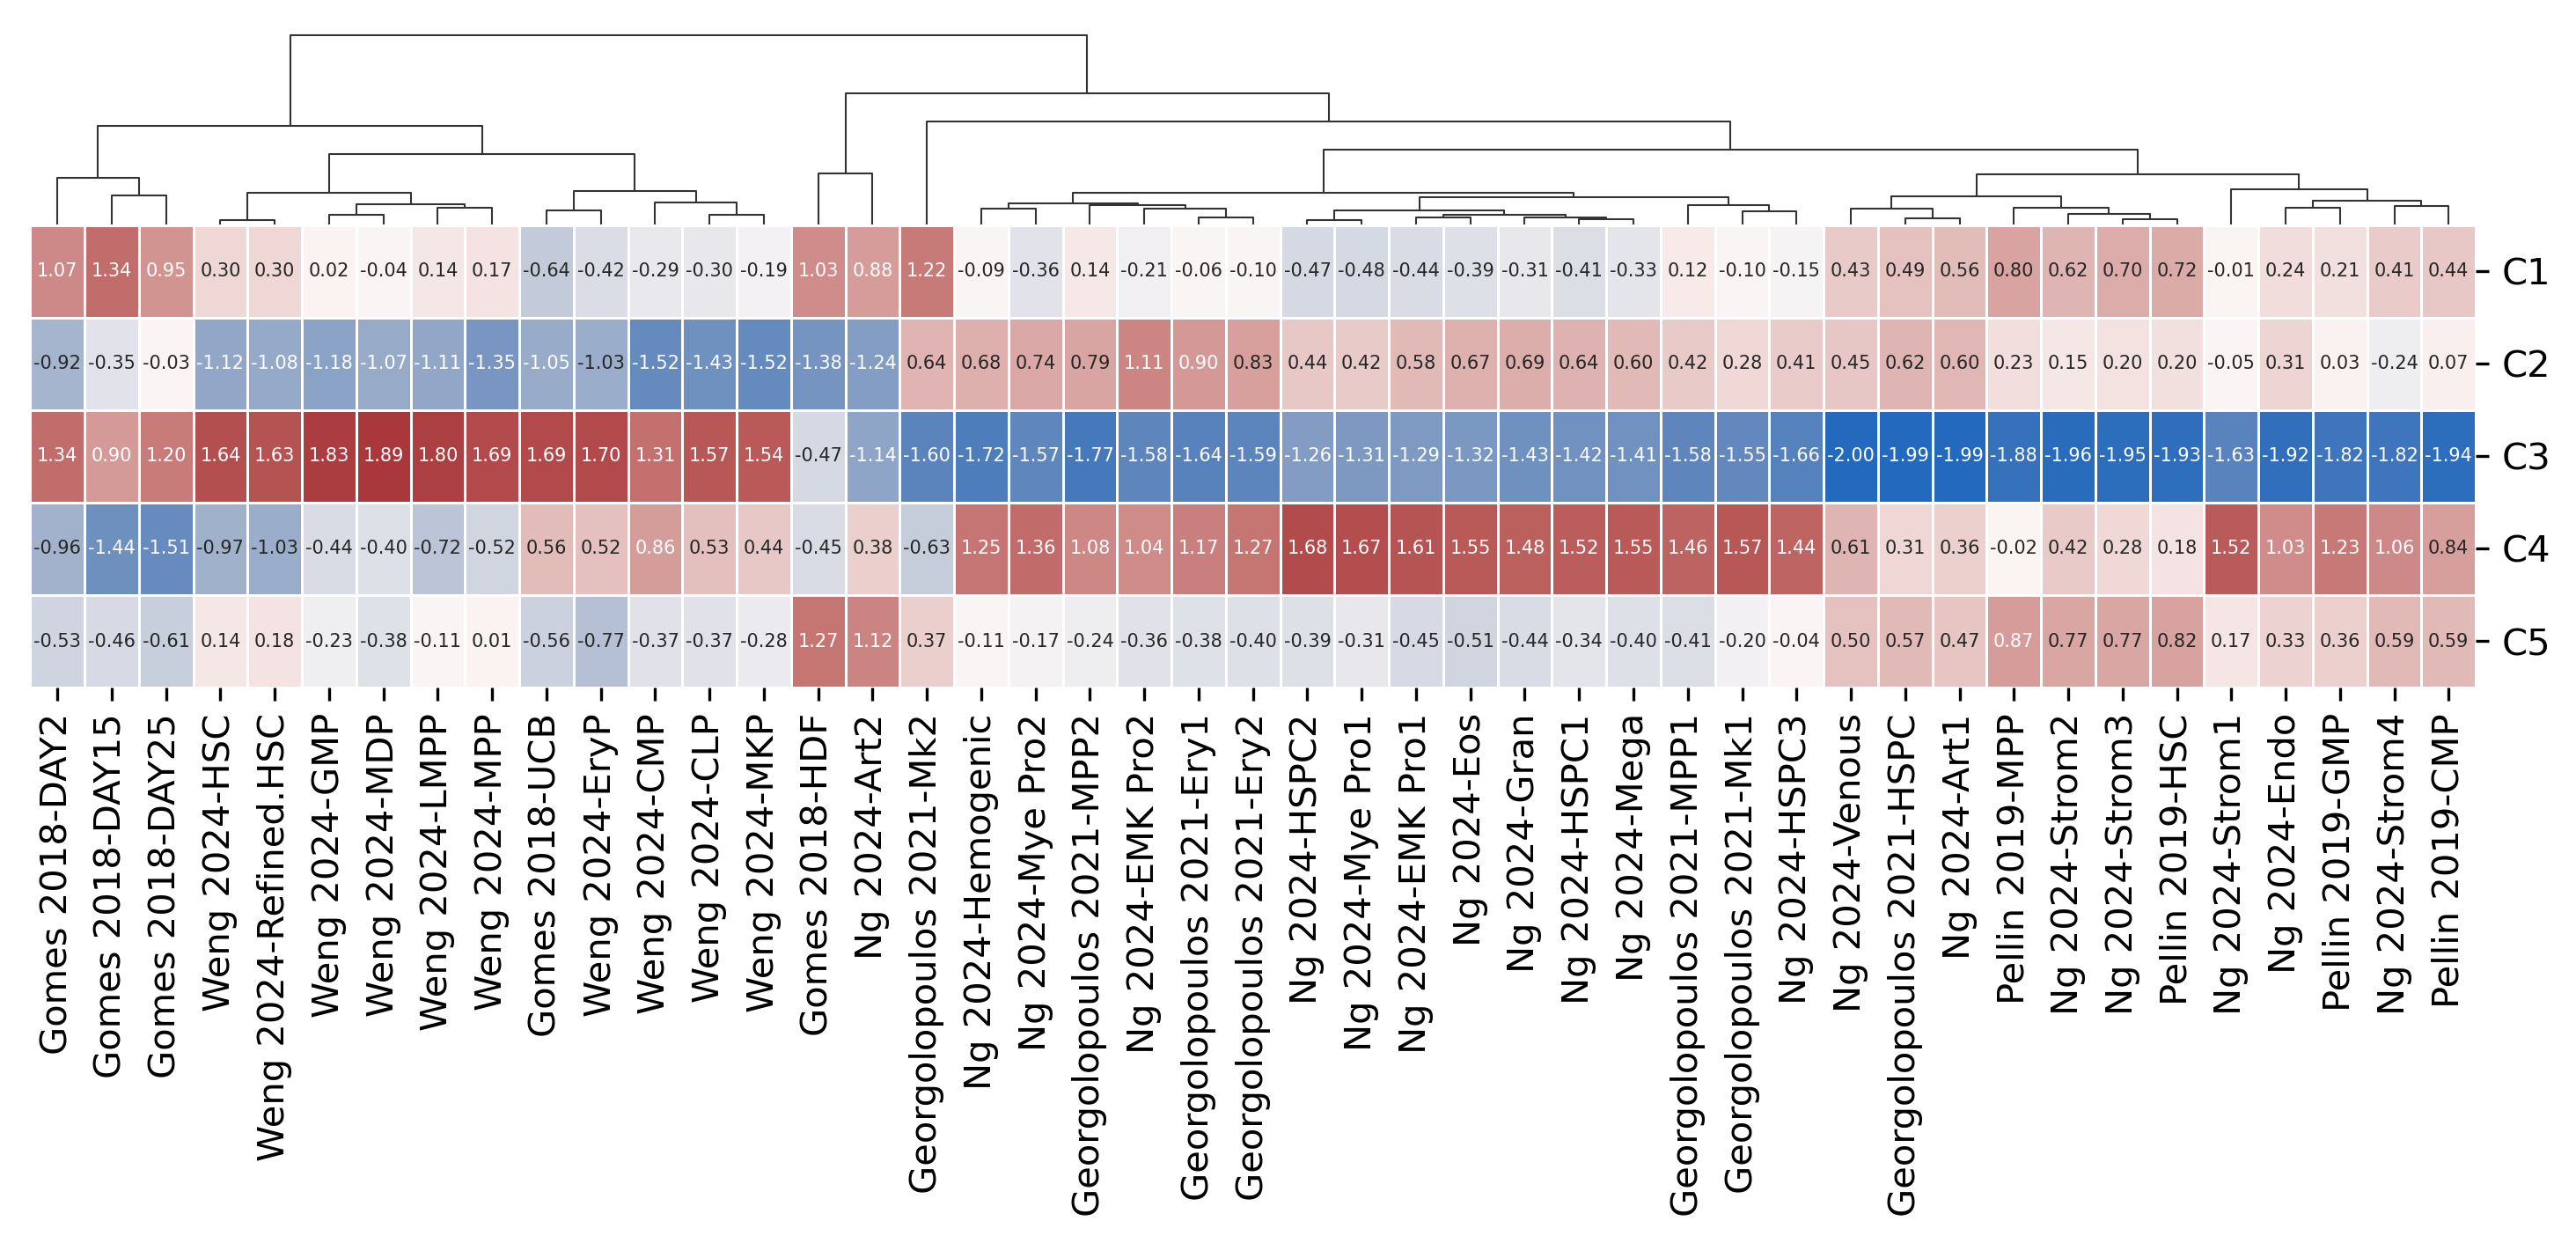

In [14]:
pdf = results.copy()

keep = [
    'DAY2', 'DAY15', 'DAY25', 'HDF', 'UCB', 'CMP', 'GMP', 'HSC',
    'MPP',  'Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2', 'Mk1',
    'Mk2', 'Refined.HSC', 'EryP', 'CLP', 'MDP', 'MKP', 'LMPP', 
    'Strom1', 'Strom2', 'Strom3', 'Strom4', 'Venous', 'Endo', 'Art1',
    'Art2', 'Hemogenic', 'HSPC1', 'HSPC2', 'HSPC3', 'EMK Pro1', 'Eos',
    'EMK Pro2', 'Mega', 'Mye Pro1', 'Mye Pro2', 'Gran'
]

pdf = pdf[pdf['r_obs'].isin(keep)]

pdf = pd.pivot_table(
    pdf, 
    index='s_obs',
    columns=['dataset', 'r_obs'],
    values='correlation'
)

print(f"{pdf.shape=}")

pdf = pdf.apply(zscore, axis=0, nan_policy='omit')

plt.rcParams['figure.dpi'] = 300

sns.clustermap(
    pdf,
    cmap='vlag',
    figsize=(10, 5),
    lw=0.25,
    cbar_pos=None,
    row_cluster=False,
    xticklabels=True,
    dendrogram_ratio=(0, 0.3),
    tree_kws={'lw' : 0.5,},
    annot=True,
    fmt=".2f",
    annot_kws={'fontsize' : 5},
)

plt.yticks(rotation=0)
plt.ylabel('')
plt.xlabel('')

# Gomes

['DAY2' 'DAY15' 'DAY25' 'HDF' 'UCB']


Text(401.148888888889, 0.5, '')

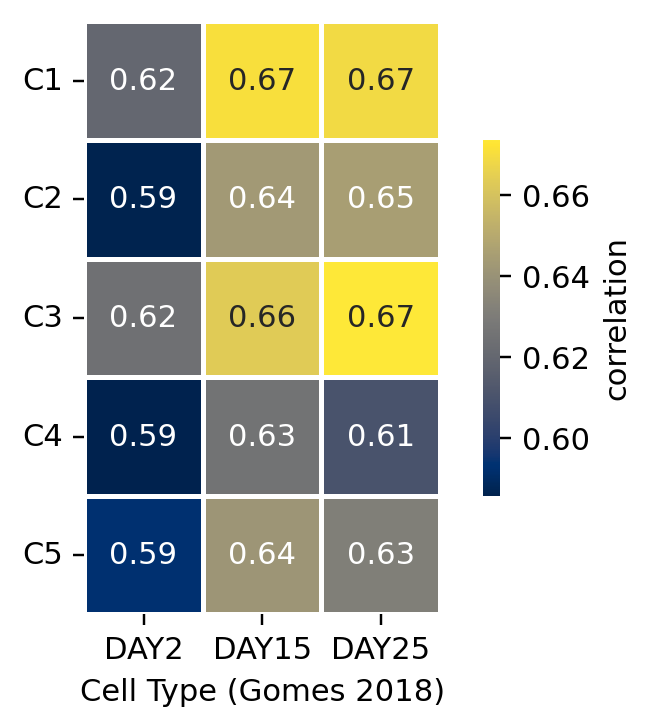

In [15]:
pdf = results.copy()

keep = [
   'Gomes 2018'
]

pdf = pdf[pdf['dataset'].isin(keep)]
print(pdf['r_obs'].unique())

plt.rcParams['figure.dpi'] = 220
plt.rcParams['figure.figsize'] = 5, 3.5

pdf = pd.pivot_table(
    pdf, 
    index='s_obs',
    columns='r_obs',
    values='correlation'
)

pdf = pdf[['DAY2', 'DAY15', 'DAY25']]
# pdf = pdf[['HDF', 'UCB']]

sns.heatmap(
    pdf, square=True,
    annot=True,
    fmt=".2f",
    cmap='cividis',
    # cmap = LinearSegmentedColormap.from_list("", ['w', 'lightgrey', 'coral', 'r']),
    robust=True,
    lw=1,
    cbar_kws={'shrink' : 0.6, 'label':'correlation'}
)

plt.yticks(rotation=0)
plt.xlabel("Cell Type (Gomes 2018)")
plt.ylabel("")

# Ng et al. 2024

> **Citation:**  
> Ng, E. S., et al. "Long-term engrafting multilineage hematopoietic cells differentiated from human induced pluripotent stem cells." *Nature Biotechnology*, pp. 1–14, Sep. 2024. [doi:10.1038/s41587-024-02360-7](https://doi.org/10.1038/s41587-024-02360-7)

---

## Data Description

**ine.ident**  
- **rm**: RM TOM iPS cells, constitutively expressing a tdTOMATO transgene from the GAPDH locus; derived from human foreskin fibroblasts.
- **pb**: PB1.1 (male), PB10.5 (male), and PB5.1 (female) iPS cells reprogrammed from peripheral blood of healthy volunteers using Sendai virus (POU5F1, SOX2, KLF4, MYC2).

**fract.ident**  
- **sn**: Isolated single cells.
- **swb**: Swirling embryoid bodies.


In [16]:
# pdf = results.copy()

# keep = [
#    'Ng 2024'
# ]

# pdf = pdf[pdf['dataset'].isin(keep)]
# print(pdf['r_obs'].unique())

# pdf['r_obs_agg'] = pdf['r_obs'].str.replace(r'\d+$', '', regex=True)
# print(pdf['r_obs_agg'].unique())

# for target in ['Strom', 'Venous', 'Endo', 'Art', 'Hemogenic', 'HSPC', 'Mega',]:

#     plt.rcParams['figure.dpi'] = 220
#     plt.rcParams['figure.figsize'] = 2, 2.25
    
#     sns.barplot(
#         data=pdf[pdf['r_obs_agg'] == target],
#         x='s_obs',
#         y='correlation',
#         hue='s_obs',
#         errorbar=None,
#         ec='k',
#         width=0.6,
#         zorder=5
#     )
#     plt.xlabel("")
#     plt.title(target)
#     sns.despine()
#     plt.grid(axis='y')
#     plt.show()


In [17]:
# pdf = results.copy()

# keep = [
#    'Ng 2024'
# ]

# pdf = pdf[pdf['dataset'].isin(keep)]
# print(pdf['r_obs'].unique())

# pdf['r_obs_agg'] = pdf['r_obs'].str.replace(r'\d+$', '', regex=True)
# print(pdf['r_obs_agg'].unique())

# pdf = pd.pivot_table(
#     pdf, 
#     index='s_obs',
#     columns='r_obs_agg',
#     values='correlation',
#     aggfunc='mean',
# )

# pdf = pdf[['Strom', 'Venous', 'Endo', 'Art', 'Hemogenic', 'HSPC', 'Mega', 'Mono']]

# print(f"{pdf.shape=}")

# plt.rcParams['figure.dpi'] = 220
# plt.rcParams['figure.figsize'] = 10, 3.5

# sns.heatmap(
#     pdf, square=True,
#     annot=True,
#     fmt=".2f",
#     cmap='cividis',
#     robust=True,
#     lw=1,
#     cbar_kws={'shrink' : 0.6, 'label':'correlation'}
# )

# plt.yticks(rotation=0)
# plt.xlabel("Cell Type (Ng 2024)")
# plt.ylabel("")

['Strom1' 'Strom2' 'Strom3' 'Strom4' 'Venous' 'Endo' 'Art1' 'Art2'
 'Hemogenic' 'HSPC1' 'HSPC2' 'HSPC3' 'EMK Pro1' 'Eos' 'EMK Pro2' 'Mega'
 'Mye Pro1' 'Mye Pro2' 'Mono' 'Gran']


Text(294.88888888888886, 0.5, '')

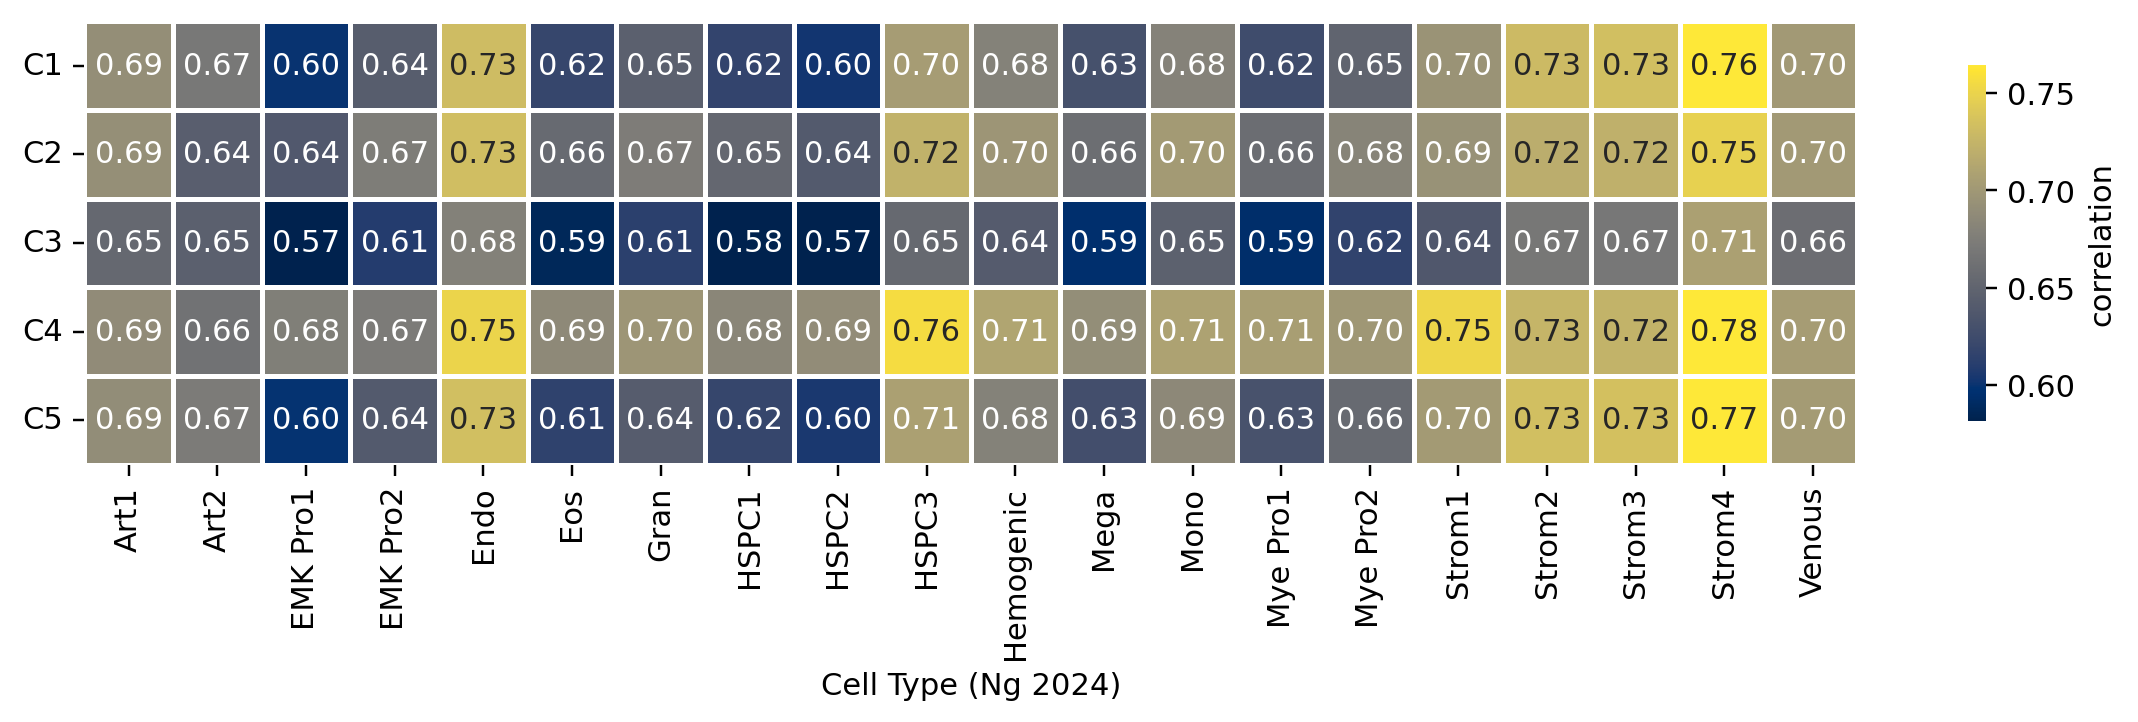

In [18]:
pdf = results.copy()

keep = [
   'Ng 2024'
]

pdf = pdf[pdf['dataset'].isin(keep)]
print(pdf['r_obs'].unique())

plt.rcParams['figure.dpi'] = 220
plt.rcParams['figure.figsize'] = 13, 3.5

pdf = pd.pivot_table(
    pdf, 
    index='s_obs',
    columns='r_obs',
    values='correlation'
)

sns.heatmap(
    pdf, square=True,
    annot=True,
    fmt=".2f",
    cmap='cividis',
    # cmap = LinearSegmentedColormap.from_list("", ['w', 'lightgrey', 'coral', 'r']),
    robust=True,
    lw=1,
    cbar_kws={'shrink' : 0.6, 'label':'correlation'}
)


plt.yticks(rotation=0)
plt.xlabel("Cell Type (Ng 2024)")
plt.ylabel("")

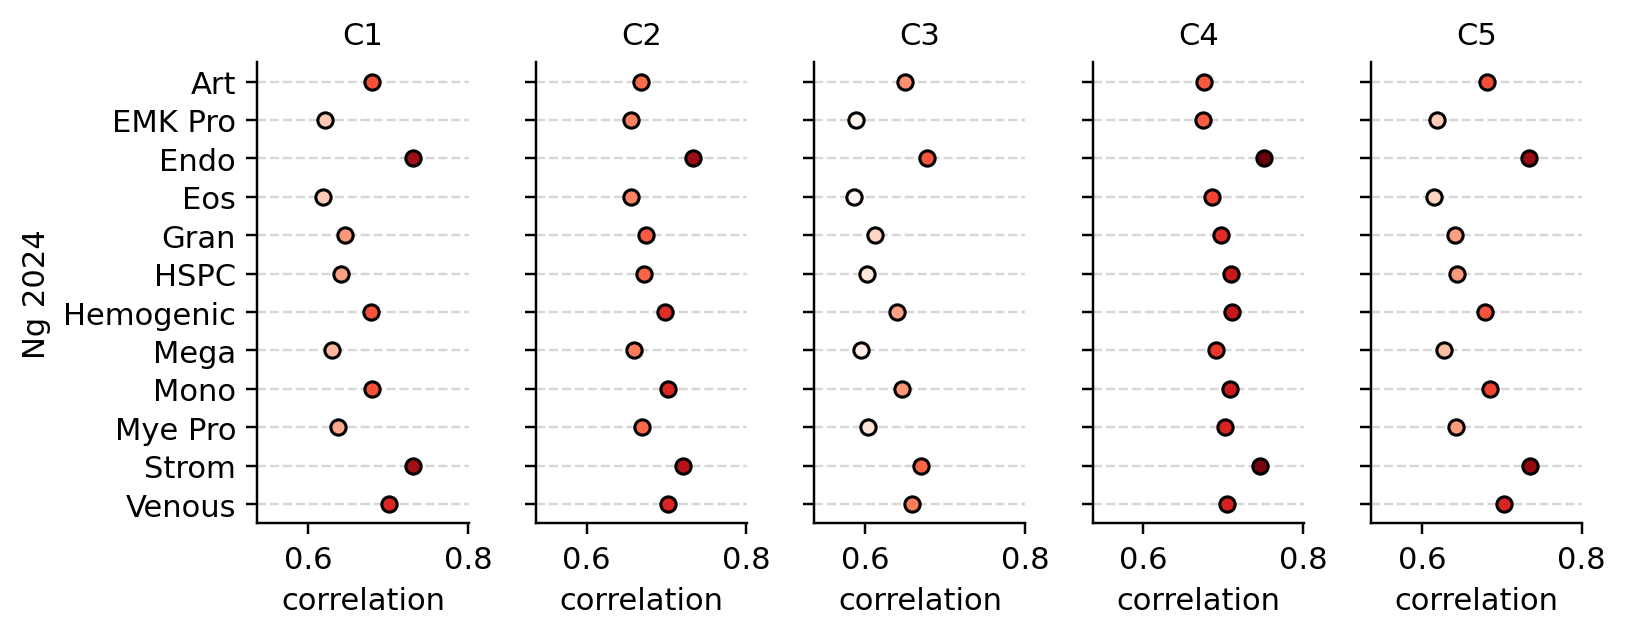

In [19]:
pdf = results.copy()

keep = [
   'Ng 2024'
]

plt.rcParams['figure.dpi'] = 220

pdf = pdf[pdf['dataset'].isin(keep)]
pdf['r_obs_agg'] = pdf['r_obs'].str.replace(r'\d+$', '', regex=True)

pdf = pdf.groupby(['s_obs', 'r_obs_agg'])['correlation'].mean().reset_index()

# Optional: sort r_obs_agg for clarity
order = sorted(pdf['r_obs_agg'].unique())

g = sns.catplot(
    data=pdf,
    x='correlation',
    y='r_obs_agg',
    col='s_obs',
    kind='strip',      # 'strip' or 'box' for mean/dispersion
    order=order,
    height=3,
    aspect=0.5,
    hue='correlation',  
    palette='Reds',
    edgecolor='k',
    linewidth=1,
    legend=False,
)

g.set_axis_labels("correlation", "Ng 2024")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xlim(pdf['correlation'].min()-0.05, pdf['correlation'].max()+0.05)

plt.tight_layout()
plt.show()



In [20]:
# %%time
# bdata = data['Ng 2024']['adata']
# gene_intersection = list(set(bdata.var_names) & set(sdata.var_names))

# bdata = bdata[:, gene_intersection].copy()
# rsc.get.anndata_to_GPU(bdata)
# rsc.pp.normalize_total(bdata, target_sum=1e4)
# rsc.pp.log1p(bdata)
# rsc.get.anndata_to_CPU(bdata)
# bdata

In [21]:
# for group_name, group in results.groupby('dataset'):
#     # print(group.to_string(index=False))

#     n_groups = group['r_obs'].nunique()

#     g = sns.catplot(
#         data=group, 
#         x="correlation",
#         y="r_obs", 
#         col="s_obs",
#         kind="strip", 
#         height=n_groups/2.5, 
#         aspect=.6,
#         size=n_groups,
#         edgecolor="black",  # <-- edge color for points
#         linewidth=n_groups/7,        # <-- edge line width
#     )
#     g.set_axis_labels("correaltion", group_name)
#     g.set_titles("{col_name}")
#     for ax in g.axes.flat:
#         ax.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.tight_layout()
#     plt.show()
#     # break

In [22]:
# for group_name, group in results.groupby('dataset'):
#     # print(group.to_string(index=False))

#     n_groups = group['r_obs'].nunique()

#     g = sns.catplot(
#         data=group, 
#         x="correlation",
#         y="s_obs", 
#         col="r_obs",
#         kind="strip", 
#         height=n_groups/2.5, 
#         aspect=.6,
#         size=n_groups,
#         edgecolor="black",  # <-- edge color for points
#         linewidth=n_groups/7,        # <-- edge line width
#     )
#     g.set_axis_labels("correaltion", group_name)
#     g.set_titles("{col_name}")
#     for ax in g.axes.flat:
#         ax.grid(axis='y', linestyle='--', alpha=0.5)

#     plt.tight_layout()
#     plt.show()
#     # break

# ElasticNet

In [23]:
%%time
def fit_elasticnet_deconvolution(
    rdata, sdata,
    alpha=0.1,
    l1_ratio=1.0,
    fit_intercept=False,
    norm_weights=True,
    max_iter=1000
):
    """
    Fit ElasticNet models to deconvolve each sample in sdata using rdata as reference.

    Returns:
        weights_df: DataFrame [cells x ref_cell_types] of weights
        errors: list of MSEs for each cell
    """
    # Reference matrix and metadata
    R = rdata.X.toarray() if hasattr(rdata.X, "toarray") else np.array(rdata.X)
    ref_cell_types = rdata.obs['cell_type'].tolist()
    # Target matrix
    A = sdata.X.toarray() if hasattr(sdata.X, "toarray") else np.array(sdata.X)
    target_names = sdata.obs_names.tolist()

    weights = []
    errors = []

    for i in range(A.shape[0]):
        x = A[i]
        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            fit_intercept=fit_intercept,
            max_iter=max_iter
        )
        model.fit(R.T, x)
        w = model.coef_
        if norm_weights:
            w = w / np.sum(np.abs(w))
        weights.append(w)
        x_pred = np.dot(R.T, w)
        mse = np.mean((x - x_pred) ** 2)
        errors.append(mse)

    weights_df = pd.DataFrame(weights, columns=ref_cell_types, index=target_names)
    return weights_df, errors

CPU times: user 2 μs, sys: 2 μs, total: 4 μs
Wall time: 5.01 μs


# study error on  Gomes

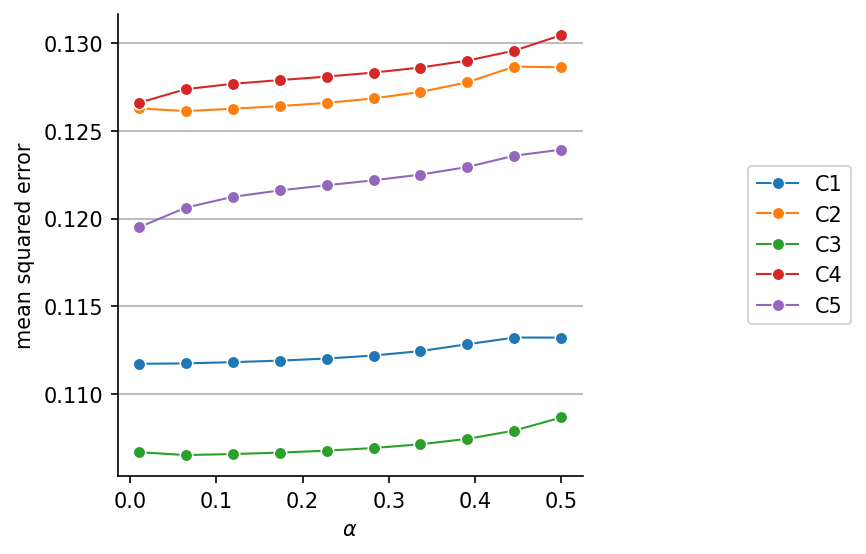

In [24]:
rdata = data['Gomes 2018']['rdata']
gene_intersection = list(set(rdata.var_names) & set(sdata.var_names))

results = []
steps = 10

for a in np.linspace(0.01, 0.5, steps):
    wdf, e = fit_elasticnet_deconvolution(
        rdata[:, gene_intersection].copy(), 
        sdata[:, gene_intersection].copy(), 
        alpha=a,
        l1_ratio=0.25,
        fit_intercept=False,
        max_iter=1000
    )
    edf = pd.DataFrame({'error' : e, 'cluster' : wdf.index})
    edf['alpha'] = a
    results.append(edf)

results = pd.concat(results)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sns.lineplot(
    data=results,
    x='alpha',
    y='error',
    hue='cluster',
    marker="o",
    lw=1,
)

plt.ylabel("mean squared error")
plt.xlabel(r"$\alpha$")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.6, 0.5),
)
sns.despine()

    

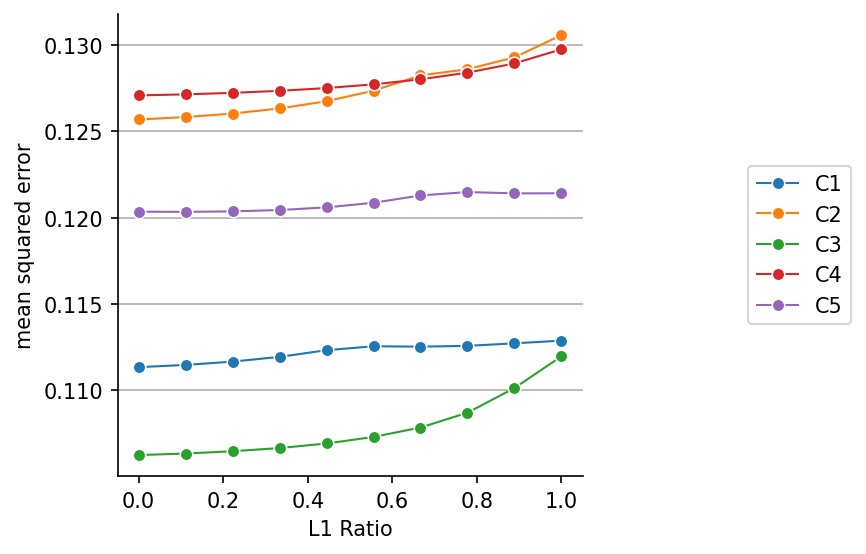

In [25]:
rdata = data['Gomes 2018']['rdata']
gene_intersection = list(set(rdata.var_names) & set(sdata.var_names))

results = []
steps = 10

for l1 in np.linspace(0.0, 1.0, steps):
    wdf, e = fit_elasticnet_deconvolution(
        rdata[:, gene_intersection].copy(), 
        sdata[:, gene_intersection].copy(), 
        alpha=0.05,
        l1_ratio=l1,
        fit_intercept=False,
        max_iter=1000
    )
    edf = pd.DataFrame({'error' : e, 'cluster' : wdf.index})
    edf['l1'] = l1
    results.append(edf)

results = pd.concat(results)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sns.lineplot(
    data=results,
    x='l1',
    y='error',
    hue='cluster',
    marker="o",
    lw=1,
)

plt.ylabel("mean squared error")
plt.xlabel(r"L1 Ratio")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.6, 0.5),
)
sns.despine()

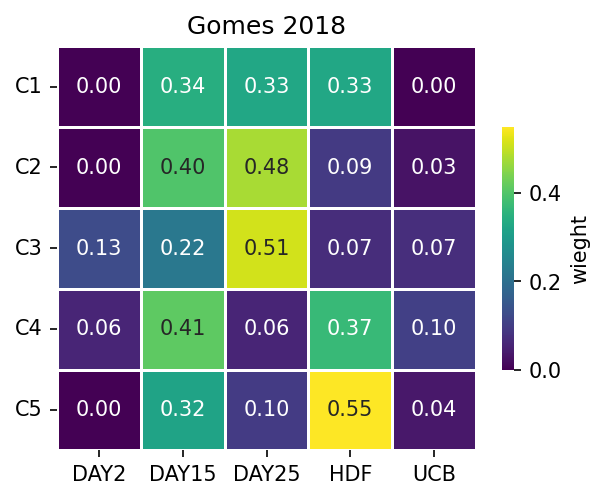

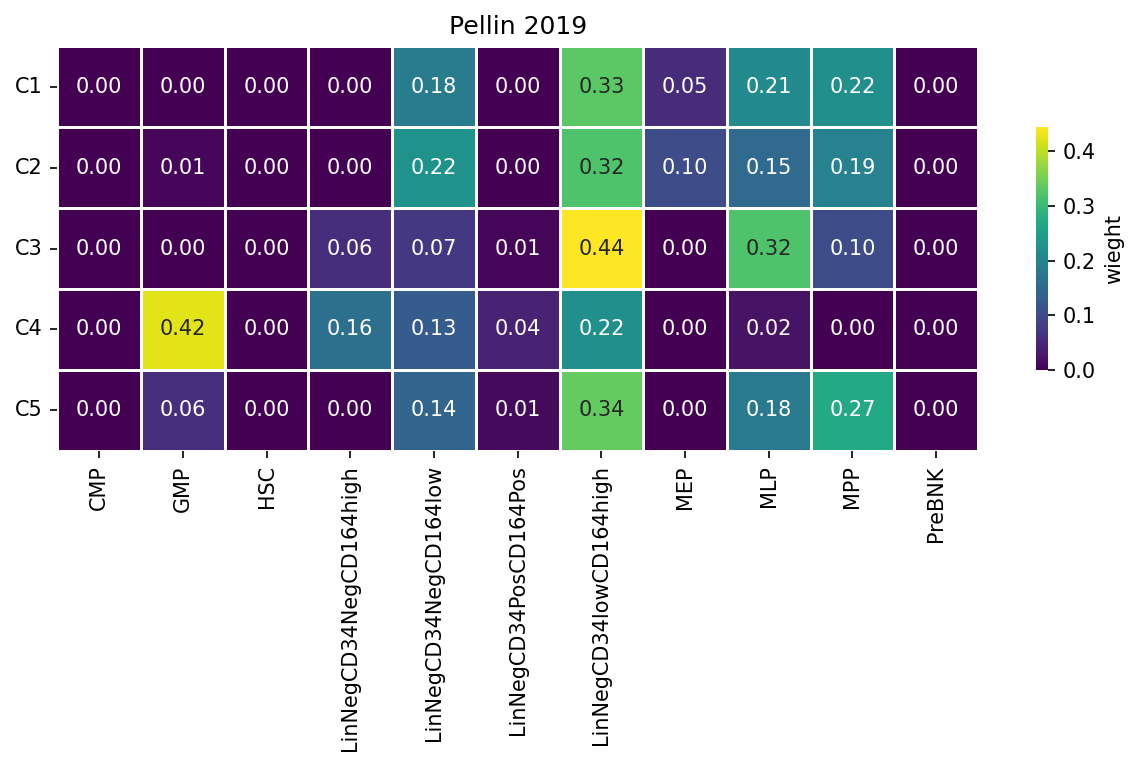

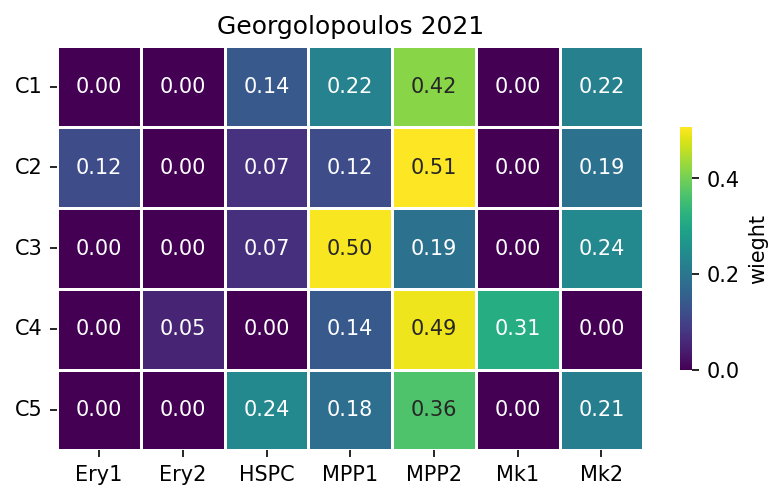

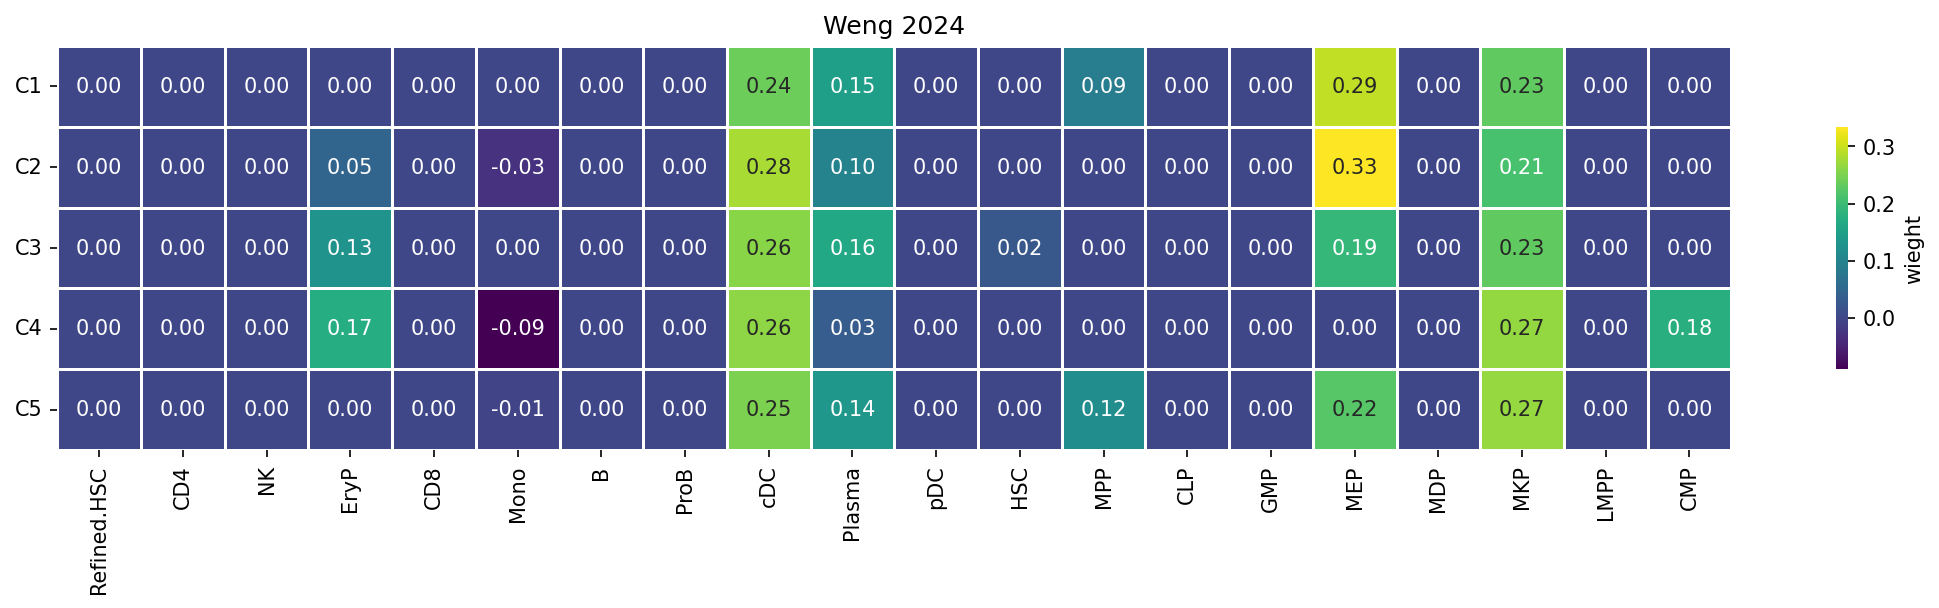

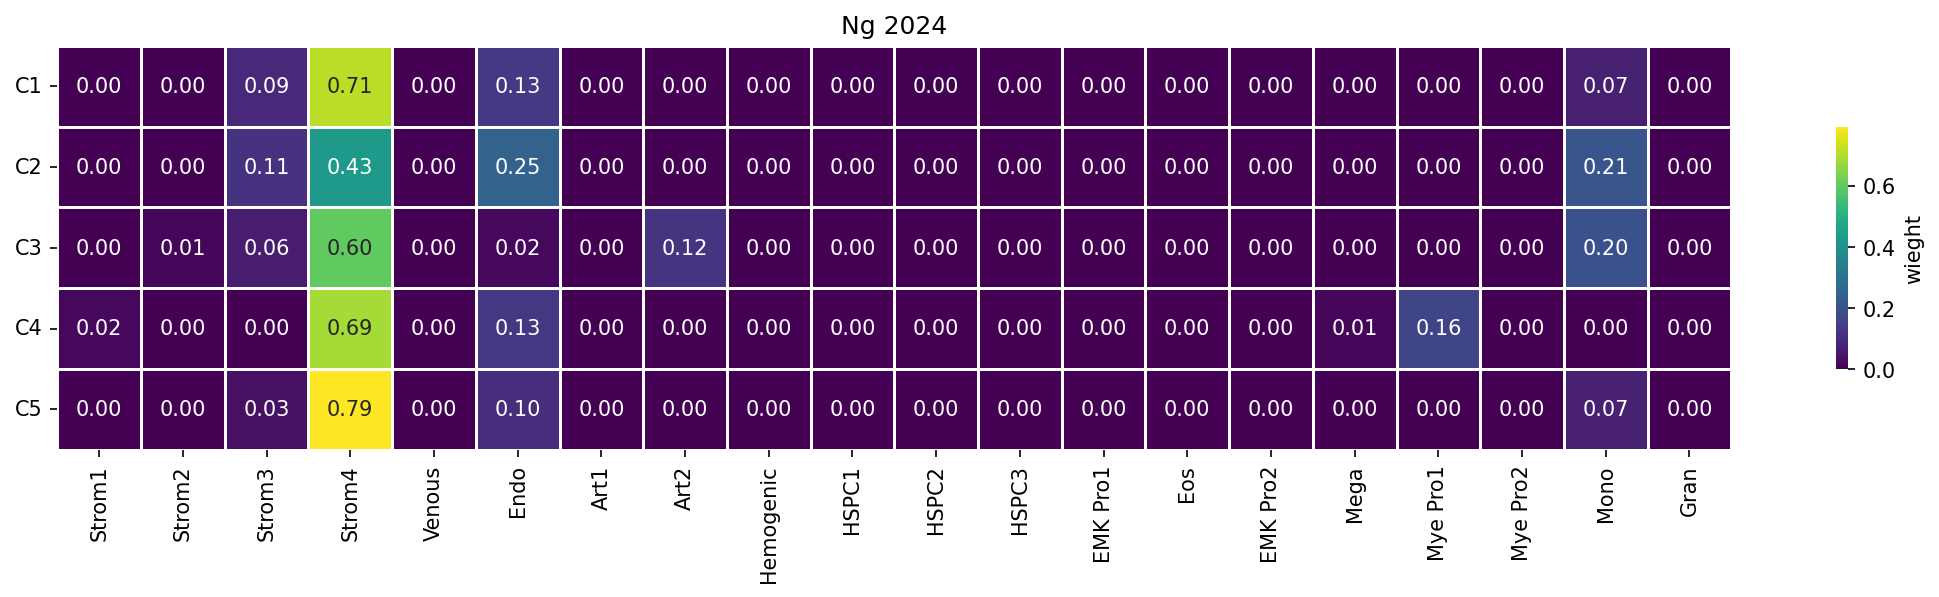

CPU times: user 1.87 s, sys: 238 ms, total: 2.11 s
Wall time: 2.86 s


,error,cluster,dataset
0,0.113056,C1,Gomes 2018
1,0.128276,C2,Gomes 2018
2,0.108142,C3,Gomes 2018
3,0.127323,C4,Gomes 2018
4,0.120590,C5,Gomes 2018


In [33]:
%%time

errors = []
threshold = 0.5

for dataset, data_dict in data.items():
    rdata = data_dict['rdata']

    gene_intersection, _, _ = top_percentile_genes_anndata(rdata, sdata, percentile=threshold)

    wdf, e = fit_elasticnet_deconvolution(
        rdata[:, gene_intersection].copy(), 
        sdata[:, gene_intersection].copy(), 
        alpha=0.01,
        l1_ratio=0.95,
        fit_intercept=False,
        max_iter=1000
    )

    plt.rcParams['figure.dpi'] = 150
    plt.rcParams['figure.figsize'] = wdf.shape[1] * 0.9, 3.5

    sns.heatmap(
        wdf,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        linewidths=0.5,
        linecolor='w',
        cbar_kws={'label': 'wieght', 'shrink' : 0.6},
    )
    
    plt.title(dataset)
    plt.xlabel("")
    plt.ylabel("")
    plt.yticks(rotation=0)
    plt.show()

    # save the error vector
    edf = pd.DataFrame({'error' : e, 'cluster' : wdf.index})
    edf['dataset'] = dataset
    errors.append(edf)


errors = pd.concat(errors)
errors.head()

# Ng 2024

[0.14948077415244448, 0.19108471896624274, 0.18073138156733357, 0.1601769022758662, 0.14478427098386035]


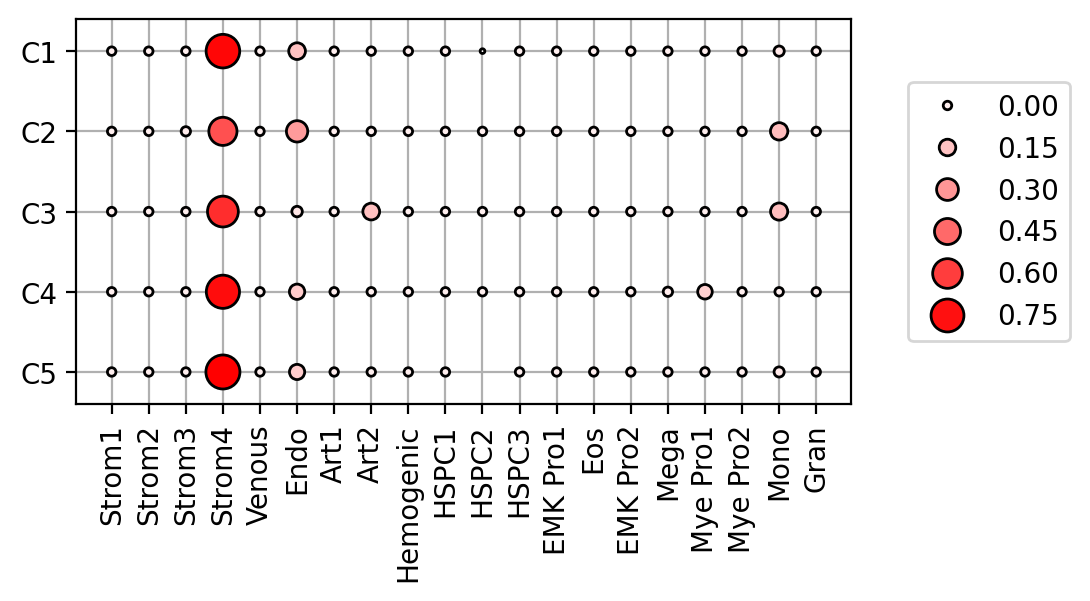

In [68]:
rdata = data['Ng 2024']['rdata']

threshold = 50 # gene expression percentile
alpha = 0.01
l1_ratio = 0.95

gene_intersection, _, _ = top_percentile_genes_anndata(rdata, sdata, percentile=threshold)

wdf, e = fit_elasticnet_deconvolution(
    rdata[:, gene_intersection].copy(), 
    sdata[:, gene_intersection].copy(), 
    alpha=alpha,
    l1_ratio=l1_ratio,
    fit_intercept=False,
    max_iter=1000
)

print(e)
wdf = wdf.reset_index()
wdf = pd.melt(wdf, id_vars='index')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 2.5

sns.scatterplot(
    data=wdf, 
    y='index',
    x='variable',
    size='value',
    hue='value',
    palette=LinearSegmentedColormap.from_list("", ['w', 'r']),
    # palette='Reds',
    sizes=(0, 150),
    zorder=5,
    ec='k',
    lw=1,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.3, 0.5),
)

plt.ylabel("")
plt.xlabel("")
plt.margins(x=0.05, y=0.1)
plt.xticks(rotation=90)
plt.grid(True)

[0.1557989143984686, 0.16244444828273244, 0.15133973402505133, 0.15026752134536753, 0.16284807781023614]


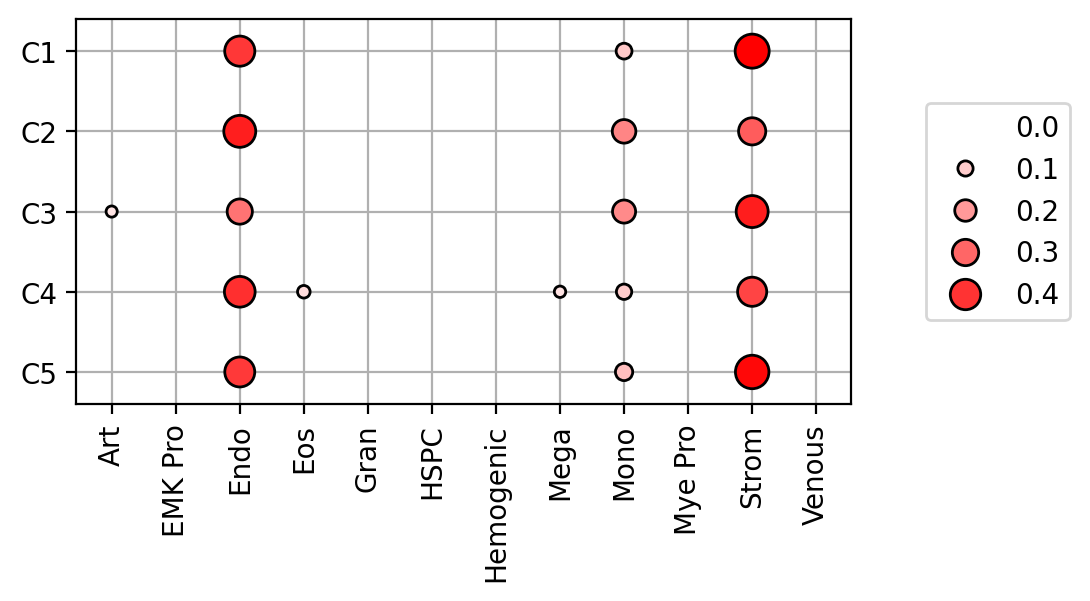

In [81]:
rdata = data['Ng 2024']['rdata']
rdata.obs['cell_group'] = rdata.obs['cell_type'].str.replace(r'\d+$', '', regex=True)

rdata = sc.get.aggregate(
    rdata,
    by='cell_group',
    func='mean',
)
    
rdata.X = rdata.layers['mean']
rdata.obs['cell_type'] = rdata.obs['cell_group']
rsc.get.anndata_to_GPU(rdata)
rsc.pp.normalize_total(rdata, target_sum=1e4)
rsc.pp.log1p(rdata)
rsc.get.anndata_to_CPU(rdata)


threshold = 5 # gene expression percentile
alpha = 0.01
l1_ratio = 0.95

gene_intersection, _, _ = top_percentile_genes_anndata(rdata, sdata, percentile=threshold)

wdf, e = fit_elasticnet_deconvolution(
    rdata[:, gene_intersection].copy(), 
    sdata[:, gene_intersection].copy(), 
    alpha=alpha,
    l1_ratio=l1_ratio,
    fit_intercept=False,
    max_iter=1000
)

print(e)
wdf = wdf.reset_index()
wdf = pd.melt(wdf, id_vars='index')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 2.5

sns.scatterplot(
    data=wdf, 
    y='index',
    x='variable',
    size='value',
    hue='value',
    palette=LinearSegmentedColormap.from_list("", ['w', 'r']),
    # palette='Reds',
    sizes=(0, 150),
    zorder=5,
    ec='k',
    lw=1,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.3, 0.5),
)

plt.ylabel("")
plt.xlabel("")
plt.margins(x=0.05, y=0.1)
plt.xticks(rotation=90)
plt.grid(True)

# Error

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Gomes 2018'),
  Text(1, 0, 'Pellin 2019'),
  Text(2, 0, 'Georgolopoulos 2021'),
  Text(3, 0, 'Weng 2024'),
  Text(4, 0, 'Ng 2024')])

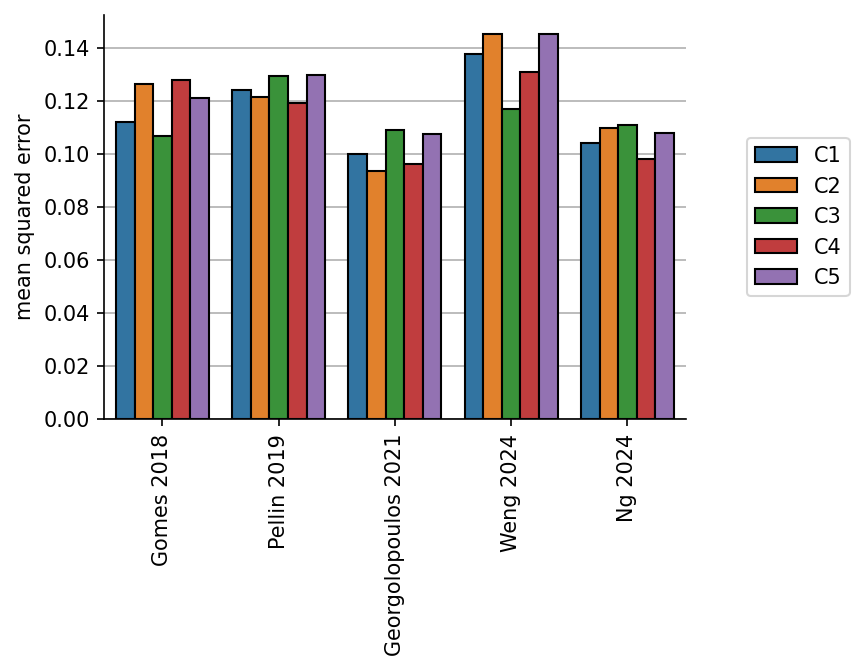

In [27]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 5, 3.5

sns.barplot(
    data=errors,
    x='dataset',
    y='error',
    hue='cluster',
    ec='k',
    zorder=4,
)

plt.ylabel("mean squared error")
plt.xlabel("")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.3, 0.5),
)
sns.despine()
plt.xticks(rotation=90)

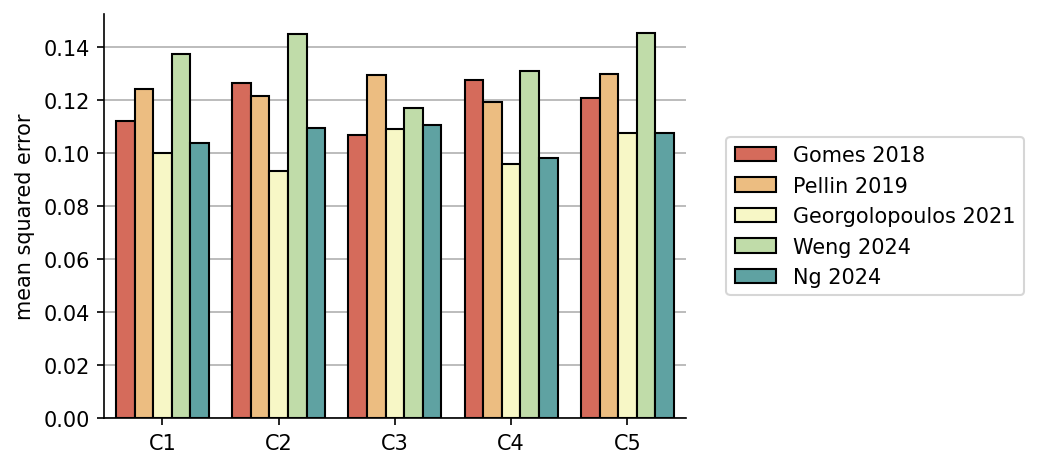

In [28]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 5, 3.5

sns.barplot(
    data=errors,
    x='cluster',
    y='error',
    hue='dataset',
    ec='k',
    zorder=4,
    palette='Spectral',
)

plt.ylabel("mean squared error")
plt.xlabel("")
plt.grid(axis='y')
sns.move_legend(
    plt.gca(),
    title="",
    loc="center right",
    bbox_to_anchor=(1.6, 0.5),
)
sns.despine()


In [29]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)